In [1]:
!pip install matplotlib
!pip install pandas
!pip install seaborn
!pip install itertools

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
from io import StringIO
import re
from math import ceil
import itertools
from collections import Counter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# Logs schneiden

In [3]:
# Pfad zur Logdatei
log_path = "sim_structural_full.log"
output_path = "sim_structural.log"

pattern = "Running simulations for: Humidity"

with open(log_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

cut_idx = None
for i, line in enumerate(lines):
    if pattern in line:
        cut_idx = i
        break

if cut_idx is not None:
    with open(output_path, "w", encoding="utf-8") as f_out:
        f_out.writelines(lines[:cut_idx])  # Alles bis zum Pattern behalten
    print(f"FERTIG! Gespeichert als {output_path}")
else:
    print("Pattern nicht gefunden.")


FERTIG! Gespeichert als sim_structural.log


#    ################################
#  0. Daten hochladen
#   ################################

In [4]:
# Load the CSV file in the same directory
df = pd.read_csv("temperature_with.csv", sep=";")

# Show first few rows
print(df.head(1000))


           Date      Time    Sensor    State  Energy Level
0    02.09.2024  09:35:25  SENSOR06  passive    100.000000
1    02.09.2024  09:35:25  SENSOR04  passive    100.000000
2    02.09.2024  09:35:25  SENSOR03  passive    100.000000
3    02.09.2024  09:35:25  SENSOR05  passive    100.000000
4    02.09.2024  09:35:25  SENSOR08   active    100.000000
..          ...       ...       ...      ...           ...
995  02.09.2024  09:47:15  SENSOR04   active     99.905613
996  02.09.2024  09:47:15  SENSOR03  passive     99.986125
997  02.09.2024  09:47:15  SENSOR05  passive     99.986125
998  02.09.2024  09:47:15  SENSOR08   active     99.940525
999  02.09.2024  09:47:15  SENSOR07  passive     99.903475

[1000 rows x 5 columns]


#    ################################
##  Sensorlist erstellen und Zeitstempel kombinieren und in datetime umwandeln (falls noch nicht geschehen)
#   ################################

In [5]:

sensor_list = df['Sensor'].unique().tolist()

# Zeitstempel kombinieren 
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d.%m.%Y %H:%M:%S')

# Die Endenergiewerte

In [6]:

# Schritt 1: Den letzten Messwert pro Sensor holen
df_sorted = df.sort_values(['Sensor', 'Timestamp'])
df_last = df_sorted.groupby('Sensor').tail(1).reset_index(drop=True)

# Schritt 2: Sortierfunktion anpassen (erst alle mit 1 am Ende, dann 2, dann Rest)
def sensor_sort_key(sensor):
    # Extrahiere Endziffer als int
    try:
        last_digit = int(sensor[-1])
        number = int(sensor[-2:])  # zweistellige Zahl am Ende
    except:
        last_digit = -1
        number = 0
    if last_digit == 1:
        return (0, number)
    elif last_digit == 2:
        return (1, number)
    else:
        return (2, number)

# Schritt 3: Nach der gewünschten Reihenfolge sortieren
df_last_sorted = df_last.copy().sort_values(
    by="Sensor", key=lambda x: x.map(sensor_sort_key)
).reset_index(drop=True)

# Schritt 4: Ergebnis anzeigen
print(df_last_sorted[['Sensor', 'Energy Level']])


      Sensor  Energy Level
0   SENSOR01     97.979913
1   SENSOR11     91.276938
2   SENSOR21     98.652063
3   SENSOR31     90.100413
4   SENSOR41     99.129963
5   SENSOR51     69.493750
6   SENSOR61     98.713563
7   SENSOR71     97.279863
8   SENSOR81     98.691175
9   SENSOR02     98.016250
10  SENSOR12     91.667388
11  SENSOR22     98.634250
12  SENSOR32     90.445975
13  SENSOR42     99.158463
14  SENSOR52     69.453850
15  SENSOR62     98.744200
16  SENSOR72     97.319050
17  SENSOR82     98.664100
18  SENSOR03     54.316337
19  SENSOR04     55.835387
20  SENSOR05     55.824700
21  SENSOR06     54.320612
22  SENSOR07     55.836100
23  SENSOR08     54.306362
24  SENSOR09     55.829687


#    ################################
#  1. Energieverlauf von einem Sensor
#   ################################

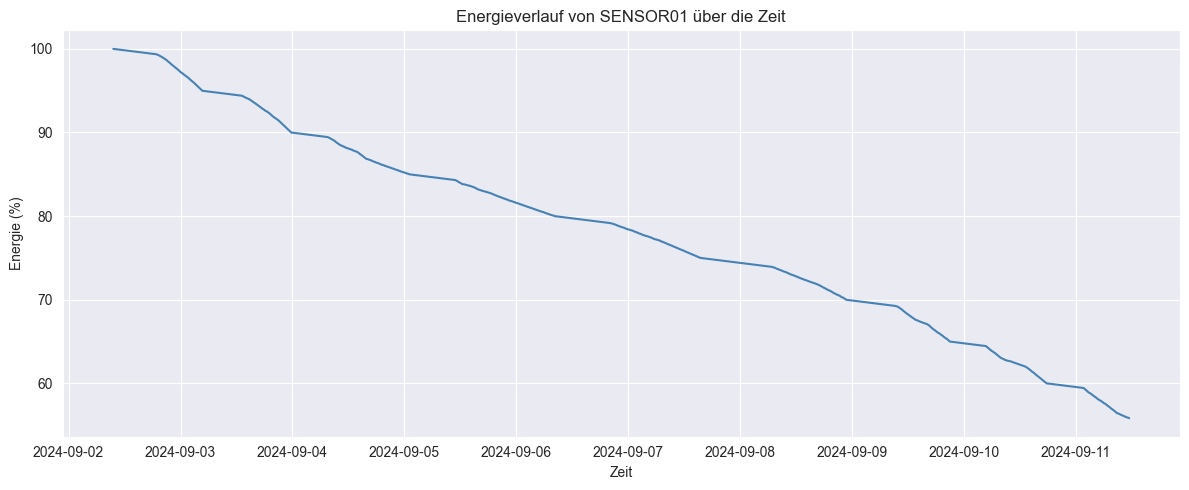

In [7]:


# SENSOR01 filtern
sensor1_data = df[df['Sensor'] == 'SENSOR05']

# Plot
plt.figure(figsize=(12,5))
plt.plot(sensor1_data['Timestamp'], sensor1_data['Energy Level'], label='SENSOR01', color='steelblue')
plt.xlabel('Zeit')
plt.ylabel('Energie (%)')
plt.title('Energieverlauf von SENSOR01 über die Zeit')
plt.grid(True)
plt.tight_layout()
plt.show()

#    ################################
#  2. Energieverlauf von allen Sensoren separat
#   ################################

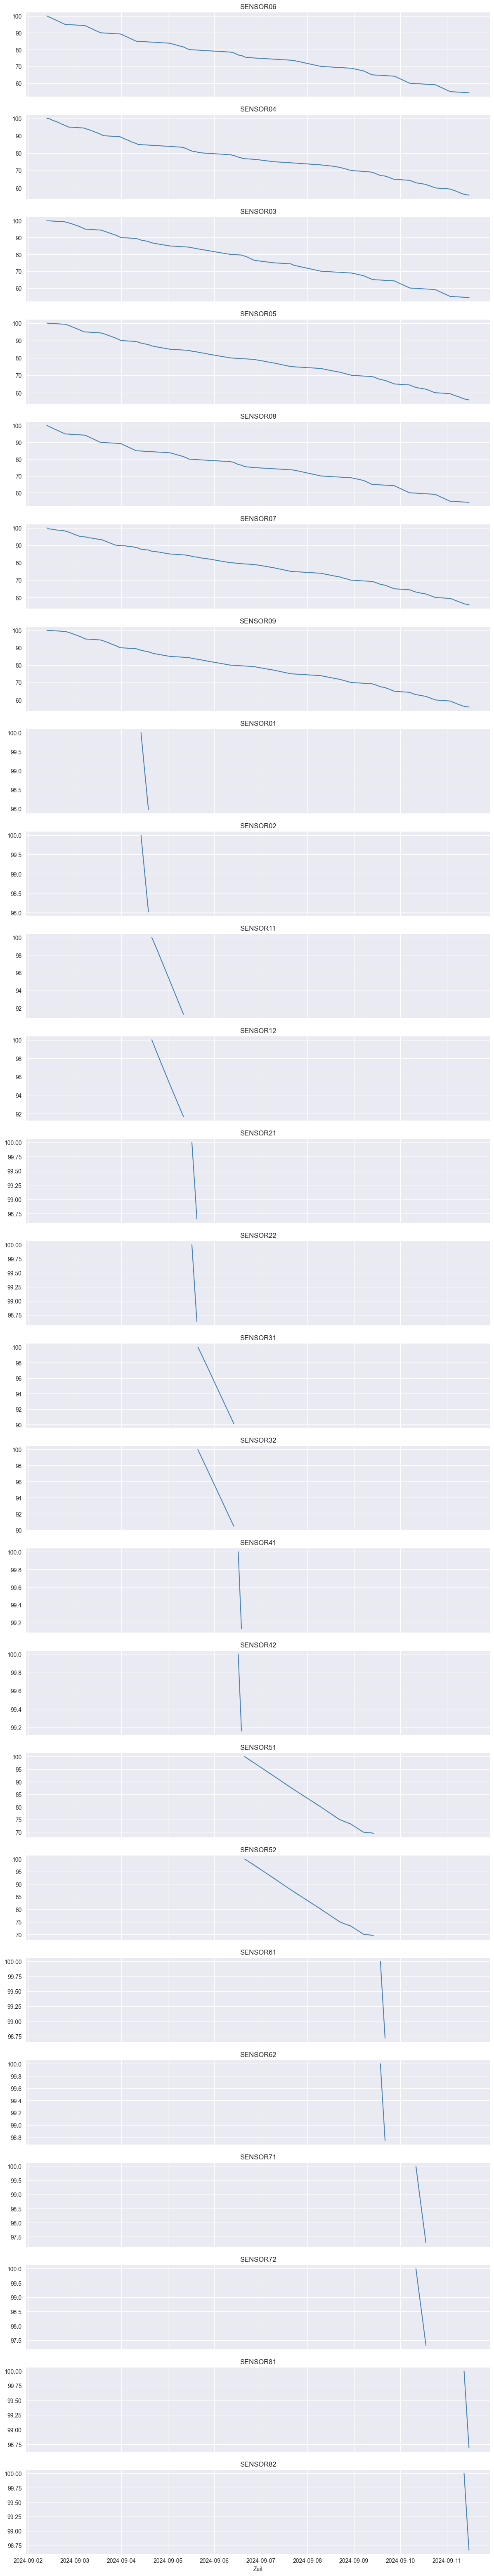

In [8]:
fig, axs = plt.subplots(nrows=len(sensor_list), figsize=(12, 2.5 * len(sensor_list)), sharex=True)
for i, sensor in enumerate(sensor_list):
    sensor_data = df[df['Sensor'] == sensor]
    axs[i].plot(sensor_data['Timestamp'], sensor_data['Energy Level'], label=sensor, color='steelblue')
    axs[i].set_title(sensor)
    axs[i].grid(True)
plt.xlabel("Zeit")
plt.tight_layout()
plt.show()



#    ################################
#  3.1. Energieverlauf von allen Sensoren zusammen.
#   ################################

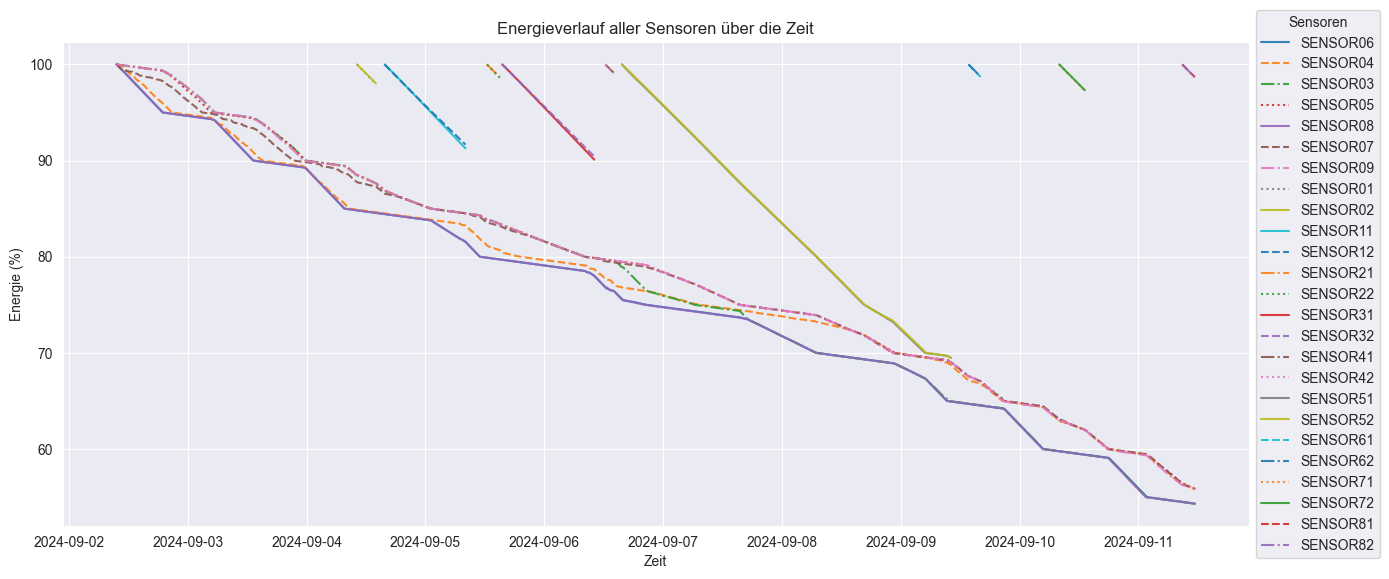

In [9]:

linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
colors = plt.cm.tab10.colors  # oder plt.cm.Set3.colors

plt.figure(figsize=(14,6))

for i, sensor in enumerate(sensor_list):
    sensor_data = df[df['Sensor'] == sensor]
    plt.plot(sensor_data['Timestamp'], sensor_data['Energy Level'],
             label=sensor,
             linestyle=linestyles[i % len(linestyles)],
             color=colors[i % len(colors)],
             alpha=0.9)

# Achsenbeschriftung und Titel
plt.xlabel('Zeit')
plt.ylabel('Energie (%)')
plt.title('Energieverlauf aller Sensoren über die Zeit')
plt.grid(True)

# Legende hinzufügen
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Sensoren')
plt.tight_layout()
plt.show()


#    ################################
#  3.2. Energieverlauf von allen Sensoren zusammen, mit hochgeladenen Activity IN/OUT Data.
#   ################################

# 3.2.1. Prepare data trashhold time


In [10]:

# Step 1: Load your threshold times
def extract_threshold_times(log_path, limit=19):
    import re
    entries = []
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            if 'Lowering rel_thr' in line:
                entries.append(line.strip())
    pattern = re.compile(
        r'\[(?P<sim_time>\d{2}\.\d{2}\.\d{4} \d{2}:\d{2}:\d{2})\]\s+Lowering rel_thr\s+'
        r'(?P<old>[0-9.]+)→(?P<new>[0-9.]+)'
    )
    records = []
    for line in entries:
        m = pattern.search(line)
        if m:
            sim_time = pd.to_datetime(m.group('sim_time'), format='%d.%m.%Y %H:%M:%S')
            old_thr = float(m.group('old'))
            new_thr = float(m.group('new'))
            records.append((sim_time, old_thr, new_thr))
    df_thr = pd.DataFrame(records, columns=['Simulationszeit', 'Alter Schwellenwert', 'Neuer Schwellenwert'])
    if limit:
        df_thr = df_thr.head(limit)
    return df_thr

def plot_threshold_lines(ax, df_thr, color='purple', style=':', label='SCHWELLENWERTANPASSUNG'):
    first = True
    for t in df_thr['Simulationszeit']:
        ax.axvline(
            t, color=color, linestyle=style, linewidth=1.5, alpha=0.8,
            label=label if first else ""
        )
        first = False
 

# 3.2.2. Plot 

# 3.2.3. Plot mit Schwellenwerten

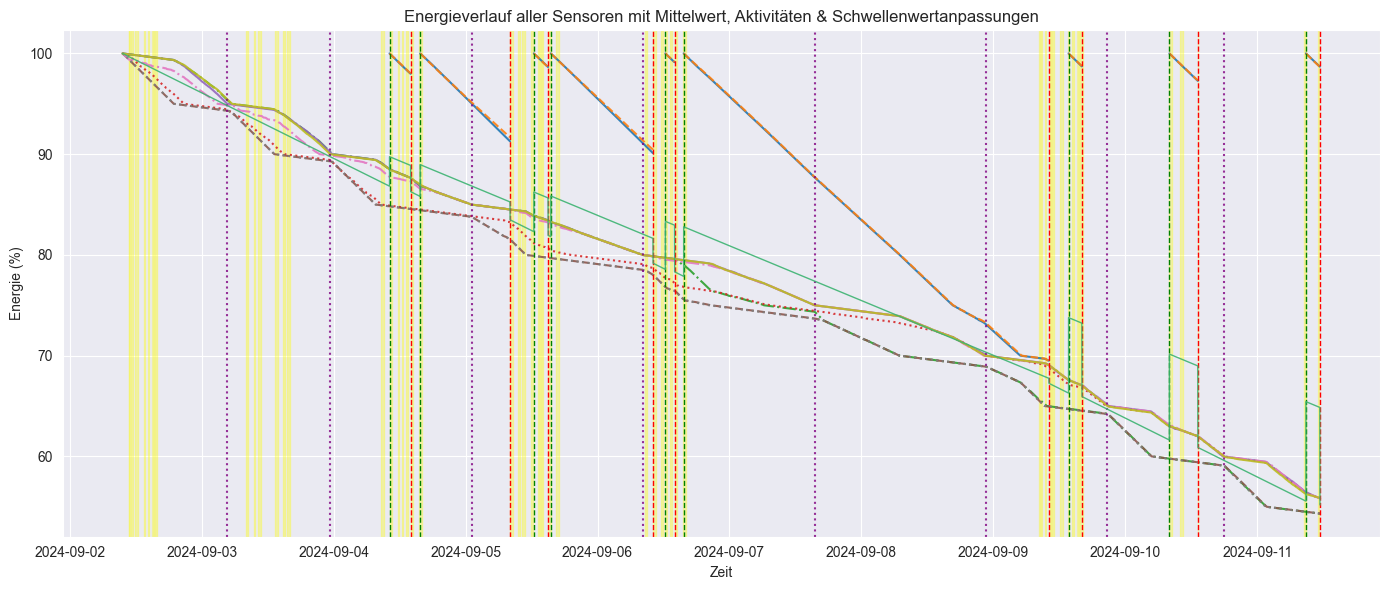

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Style definitions ---
group_styles = {
    '1':  {'linestyle': '-',  'color': plt.cm.tab10.colors[0]},
    '2': {'linestyle': '--', 'color': plt.cm.tab10.colors[1]}
}
fallback_linestyles = ['-.', ':', '-', '--']
fallback_colors     = plt.cm.tab10.colors[2:]

# --- Activity events ---
activity_data = pd.read_csv('experiment_actions.csv', sep=';', header=0)
activity_data['Start'] = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['Start Time'])
activity_data['End']   = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['End Time'])
start_time = df['Timestamp'].min()
end_time   = df['Timestamp'].max()
activity_filtered = activity_data[
    (activity_data['Start'] >= start_time) & (activity_data['End'] <= end_time)
]

# --- Load threshold events ---
df_thr = extract_threshold_times('sim_structural.log')
# # --- cut the threshold only for Humidity ---
# df_thr = df_thr.iloc[9:18]
# --- cut the threshold only for Temperature ---
df_thr = df_thr.iloc[0:9]

# --- Sensorliste extrahieren ---
sensor_list = sorted(df['Sensor'].unique())

# --- PLOT ---
fig, ax = plt.subplots(figsize=(14, 6))

# 1. Plot all sensor lines
fb_ls_idx, fb_col_idx = 0, 0
for sensor in sensor_list:
    sensor_data = df[df['Sensor'] == sensor]
    # Style
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1
    ax.plot(
        sensor_data['Timestamp'],
        sensor_data['Energy Level'],
        label=sensor,
        linestyle=style['linestyle'],
        color=style['color'],
        alpha=0.9
    )

# *** Mittelwertlinie einzeichnen ***
durchschn_energy = df.groupby('Timestamp')['Energy Level'].mean()
ax.plot(
    durchschn_energy.index,
    durchschn_energy.values,
    label='Durchschnittsenergie',
    color='mediumseagreen',
    linewidth=1,
    alpha=0.9,
    zorder=10
)

# 2. Plot activity overlays (Tür/Produkte rein/raus)
door_labeled    = False
product_labeled = {'in': False, 'out': False}
current_in_time = None
for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        ax.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.3,
            label='Tür geöffnet' if not door_labeled else ""
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        ax.axvline(
            current_in_time,
            color='green', linestyle='--', linewidth=1,
            label='Produkte hinein' if not product_labeled['in'] else ""
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        ax.axvline(
            row['Start'],
            color='red', linestyle='--', linewidth=1,
            label='Produkte hinaus' if not product_labeled['out'] else ""
        )
        product_labeled['out'] = True
        current_in_time = None

# 3. Plot threshold lines (purple, dotted)
plot_threshold_lines(ax, df_thr, color='purple', style=':', label='Schwellenwertanpassung')

# 4. Final touches
ax.set_xlabel('Zeit')
ax.set_ylabel('Energie (%)')
ax.set_title('Energieverlauf aller Sensoren mit Mittelwert, Aktivitäten & Schwellenwertanpassungen')
ax.grid(True)
plt.tight_layout()
plt.show()


# 3.2.3.2 Die Legende Separat plotten

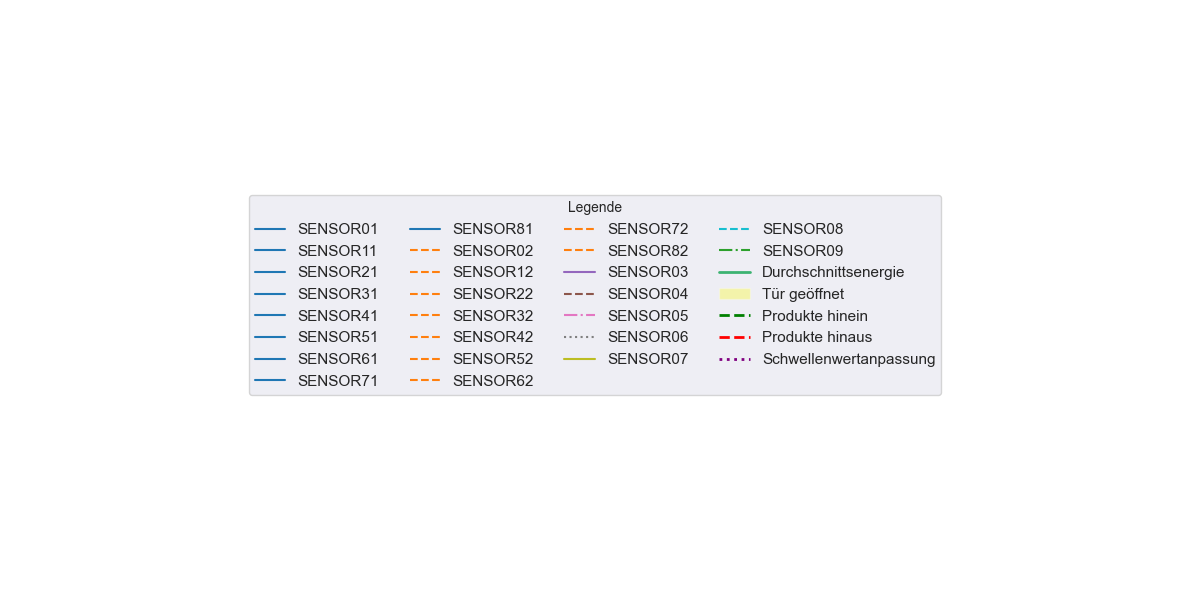

In [13]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Sensoren in drei Gruppen sortieren:
s1 = sorted([s for s in sensor_list if s.endswith('1')])
s2 = sorted([s for s in sensor_list if s.endswith('2')])
s_rest = sorted([s for s in sensor_list if not (s.endswith('1') or s.endswith('2'))])

# Neu zusammensetzen:
custom_sorted_sensor_list = s1 + s2 + s_rest

sensor_handles = []
for sensor in custom_sorted_sensor_list:
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[custom_sorted_sensor_list.index(sensor) % len(fallback_linestyles)],
            'color':     fallback_colors[custom_sorted_sensor_list.index(sensor) % len(fallback_colors)]
        }
    handle = Line2D([0], [0], label=sensor, linestyle=style['linestyle'], color=style['color'])
    sensor_handles.append(handle)

# --- Durchschnittsenergie-Linie ---
mean_energy_handle = Line2D(
    [0], [0], color='mediumseagreen', linewidth=2, label='Durchschnittsenergie'
)

# Events wie gewohnt hinzufügen
event_handles = [
    Patch(facecolor='yellow', alpha=0.3, label='Tür geöffnet'),
    Line2D([0], [0], color='green', linestyle='--', lw=2, label='Produkte hinein'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='Produkte hinaus'),
    Line2D([0], [0], color='purple', linestyle=':', lw=2, label='Schwellenwertanpassung')
]

all_handles = sensor_handles + [mean_energy_handle] + event_handles

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.legend(
    handles=all_handles,
    loc='center',
    fontsize=11,
    title='Legende',
    ncol=4
)
plt.tight_layout()
plt.show()


C:\Users\grigo\AppData\Local\Temp\ipykernel_11320\1309788817.py:137: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\grigo\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


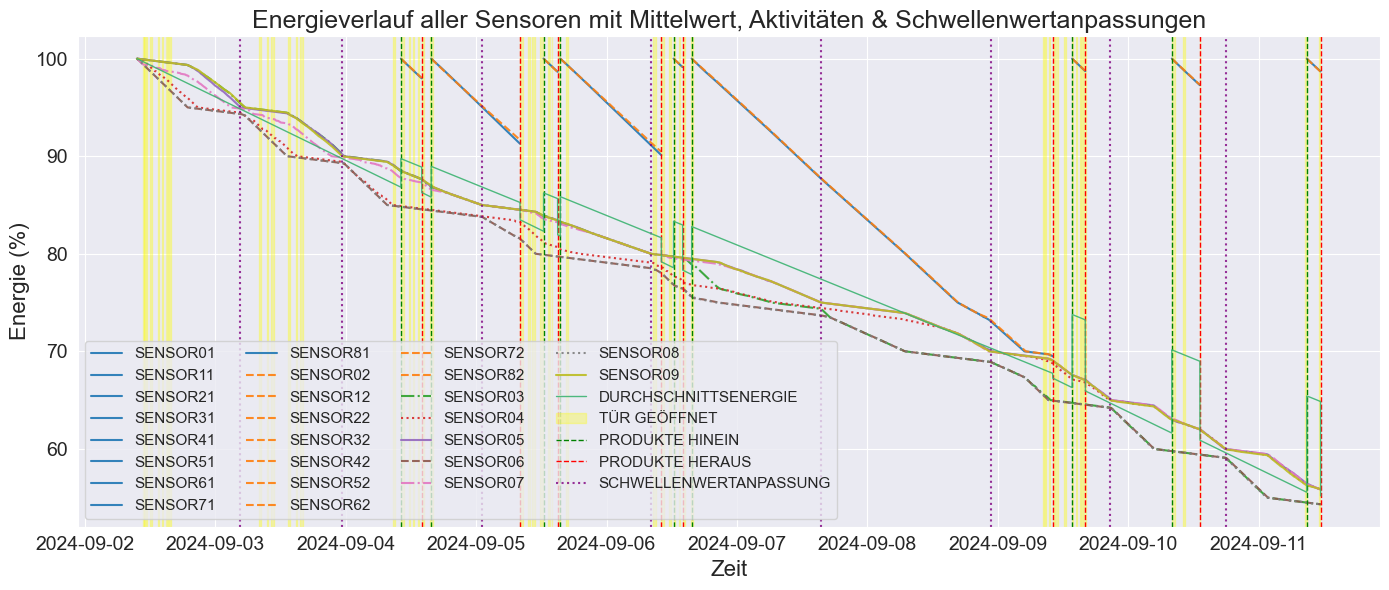

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle

# --- Style definitions ---
group_styles = {
    '1':  {'linestyle': '-',  'color': plt.cm.tab10.colors[0]},
    '2': {'linestyle': '--', 'color': plt.cm.tab10.colors[1]}
}
fallback_linestyles = ['-.', ':', '-', '--']
fallback_colors     = plt.cm.tab10.colors[2:]

# --- Load threshold events ---
df_thr = extract_threshold_times('sim_structural.log')
# --- cut the threshold only for Temperature ---
df_thr = df_thr.iloc[0:9]

# --- Sensorliste extrahieren ---
sensor_list = sorted(df['Sensor'].unique())

# --- Speicher-Objekt für spätere Legende ---
sensor_styles = dict()

# --- PLOT ---
fig, ax = plt.subplots(figsize=(14, 6))

fb_ls_idx, fb_col_idx = 0, 0
for sensor in sensor_list:
    sensor_data = df[df['Sensor'] == sensor]
    # Style
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1
    ax.plot(
        sensor_data['Timestamp'],
        sensor_data['Energy Level'],
        label=sensor,
        linestyle=style['linestyle'],
        color=style['color'],
        alpha=0.9
    )
    # *** Save the style ***
    sensor_styles[sensor] = style

# *** Mittelwertlinie einzeichnen ***
durchschn_energy = df.groupby('Timestamp')['Energy Level'].mean()
ax.plot(
    durchschn_energy.index,
    durchschn_energy.values,
    label='DURCHSCHNITTSENERGIE',
    color='mediumseagreen',
    linewidth=1,
    alpha=0.9,
    zorder=10
)

# 2. Plot activity overlays (Tür/Produkte rein/raus)
door_labeled    = False
product_labeled = {'in': False, 'out': False}
current_in_time = None
for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        ax.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.3,
            label='TÜR GEÖFFNET' if not door_labeled else ""
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        ax.axvline(
            current_in_time,
            color='green', linestyle='--', linewidth=1,
            label='PRODUKTE HINEIN' if not product_labeled['in'] else ""
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        ax.axvline(
            row['Start'],
            color='red', linestyle='--', linewidth=1,
            label='PRODUKTE HERAUS' if not product_labeled['out'] else ""
        )
        product_labeled['out'] = True
        current_in_time = None

# 3. Plot threshold lines (purple, dotted)
plot_threshold_lines(ax, df_thr, color='purple', style=':', label='SCHWELLENWERTANPASSUNG')

# 4. Final touches
ax.set_xlabel('Zeit', fontsize=16)
ax.set_ylabel('Energie (%)', fontsize=16)
ax.set_title('Energieverlauf aller Sensoren mit Mittelwert, Aktivitäten & Schwellenwertanpassungen', fontsize=18)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# ======= LEGENDE IN WUNSCHREIHENFOLGE =======
custom_sorted_sensor_list = [
    "SENSOR01", "SENSOR11", "SENSOR21", "SENSOR31", "SENSOR41",
    "SENSOR51", "SENSOR61", "SENSOR71", "SENSOR81",
    "SENSOR02", "SENSOR12", "SENSOR22", "SENSOR32", "SENSOR42",
    "SENSOR52", "SENSOR62", "SENSOR72", "SENSOR82",
    "SENSOR03", "SENSOR04", "SENSOR05", "SENSOR06", "SENSOR07", "SENSOR08", "SENSOR09"
]
# Handles der Sensoren in Wunschreihenfolge
handles, labels = ax.get_legend_handles_labels()
sensor_handles = []
sensor_labels = []
for sensor in custom_sorted_sensor_list:
    for h, l in zip(handles, labels):
        if l == sensor:
            sensor_handles.append(h)
            sensor_labels.append(l)
# Event-/Extra-Handles am Ende ergänzen (Restliche Labels außer Sensoren)
event_handles = []
event_labels = []
for h, l in zip(handles, labels):
    if l not in custom_sorted_sensor_list:
        event_handles.append(h)
        event_labels.append(l)
# Zusammenführen & Legende neu setzen
all_handles = sensor_handles + event_handles
all_labels  = sensor_labels  + event_labels
ax.legend(all_handles, all_labels, fontsize=11, ncol=4)

ax.grid(True)
plt.tight_layout()
plt.show()

# --- SENSOR-STYLES speichern, um später dieselben Farben/Linienstile wiederzuverwenden! ---
import pickle
with open("sensor_styles.pkl", "wb") as f:
    pickle.dump(sensor_styles, f)


#    ################################
#  4. Energieabweichung der einzelnen Sensoren vom Mittelwert der Energie über allen Sensoren
#   ################################

#    ################################
#  4.1 Energieabweichung der einzelnen Sensoren vom Mittelwert der Energie über allen Sensoren innerhalb der Treshold 5?
#   ################################

In [15]:
def plot_threshold_lines_plt(df_thr, color='purple', style=':', label='Schwellenwertanpassung'):
    """
    Plots vertical lines at each threshold-change timestamp in a plt-figure (not axis-based).
    """
    first = True
    for t in df_thr['Simulationszeit']:
        plt.axvline(
            t, color=color, linestyle=style, linewidth=1.5, alpha=0.8,
            label=label if first else ""
        )
        first = False

        
        
        ## later on needed only the following lines for every plot to add the purple threshold lines 
#         # <--- SCHWELLENWERT-LINIEN HINZUFÜGEN!
 #  -----> THIS LINE ALONE   # plot_threshold_lines_plt(df_thr)


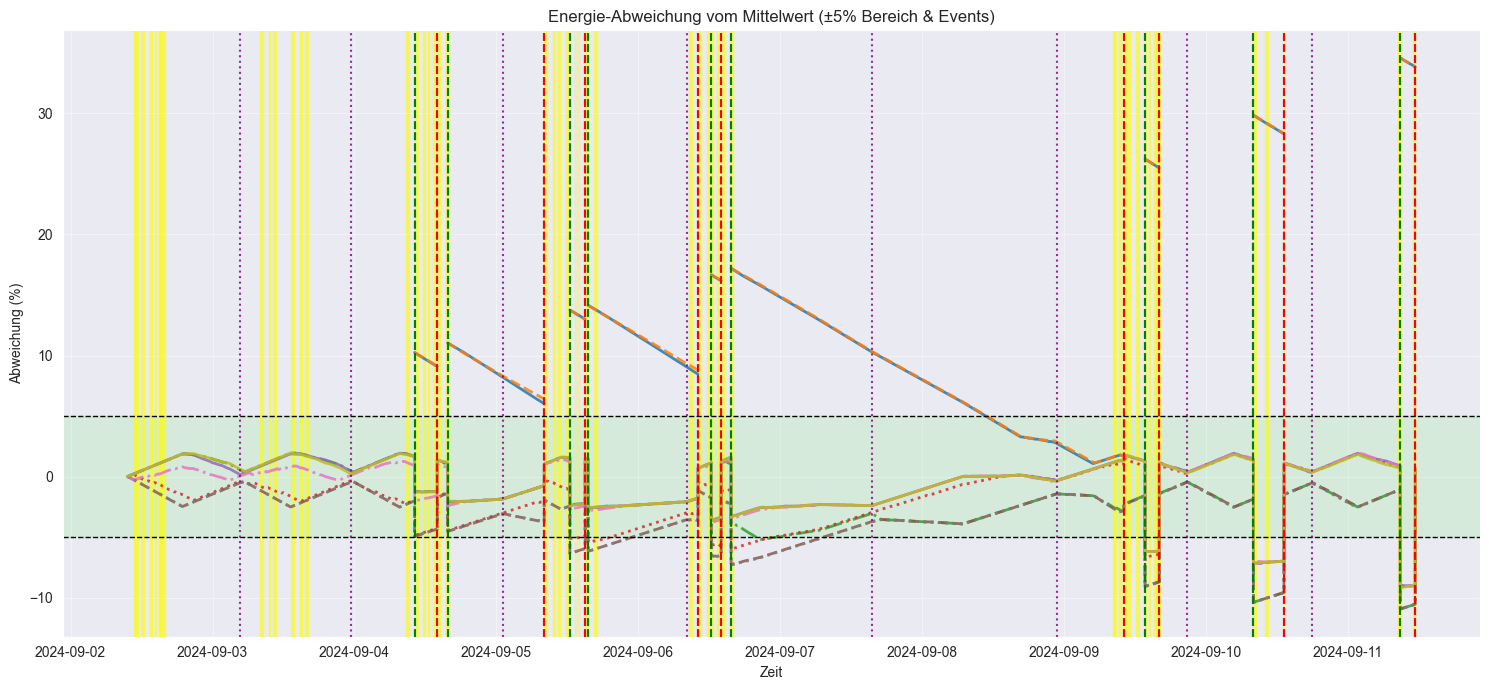

In [16]:

# 1) Mittelwert und Abweichung berechnen (falls nicht schon gemacht)
df['Mean Energy'] = df.groupby('Timestamp')['Energy Level'].transform('mean')
df['Deviation']   = df['Energy Level'] - df['Mean Energy']

threshold = 5.0

plt.figure(figsize=(15, 7))

# --- Grüner Bereich für ±5% ---
plt.axhspan(-threshold, threshold, color='lightgreen', alpha=0.22, label='±5% Bereich')

# --- Gruppendefinitionen für Endziffern ---
group_styles = {
    '1': {'linestyle': '-',  'color': plt.cm.tab10.colors[0]},
    '2': {'linestyle': '--', 'color': plt.cm.tab10.colors[1]}
}
fallback_linestyles = ['-.', ':', '-', '--']
fallback_colors     = plt.cm.tab10.colors[2:]

fb_ls_idx = fb_col_idx = 0

# --- Alle Sensoren zeichnen ---
for sensor in sensor_list:
    sensor_data = df[df['Sensor'] == sensor]
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1

    plt.plot(
        sensor_data['Timestamp'],
        sensor_data['Deviation'],
        label=sensor,
        linestyle=style['linestyle'],
        color=style['color'],
        linewidth=2,
        alpha=0.85
    )

# --- Event-Overlays ---
activity_data = pd.read_csv('experiment_actions.csv', sep=';', header=0)
activity_data['Start'] = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['Start Time'])
activity_data['End']   = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['End Time'])
start_time = df['Timestamp'].min()
end_time   = df['Timestamp'].max()
activity_filtered = activity_data[
    (activity_data['Start'] >= start_time) &
    (activity_data['End']   <= end_time)
]

door_labeled    = False
product_labeled = {'in': False, 'out': False}
current_in_time = None

for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        plt.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.3,
            label='Door opened' if not door_labeled else ""
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        plt.axvline(
            current_in_time,
            color='green', linestyle='--', linewidth=1.5,
            label='Products in' if not product_labeled['in'] else ""
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        plt.axvline(
            row['Start'],
            color='red', linestyle='--', linewidth=1.5,
            label='Products out' if not product_labeled['out'] else ""
        )
        product_labeled['out'] = True
        current_in_time = None
        
# 2. Plot activity overlays (Tür/Produkte rein/raus)
door_labeled    = False
product_labeled = {'in': False, 'out': False}
current_in_time = None
for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        plt.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.3,
            label='Tür geöffnet' if not door_labeled else ""   ### DEUTSCH
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        plt.axvline(
            current_in_time,
            color='green', linestyle='--', linewidth=1.5,
            label='Produkte hinein' if not product_labeled['in'] else ""  ### DEUTSCH
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        plt.axvline(
            row['Start'],
            color='red', linestyle='--', linewidth=1.5,
            label='Produkte hinaus' if not product_labeled['out'] else ""   ### DEUTSCH
        )
        product_labeled['out'] = True
        current_in_time = None


plt.axhline(threshold, color='black', linestyle='--', linewidth=1)
plt.axhline(-threshold, color='black', linestyle='--', linewidth=1)

# <--- SCHWELLENWERT-LINIEN HINZUFÜGEN!
plot_threshold_lines_plt(df_thr)

plt.title("Energie-Abweichung vom Mittelwert (±5% Bereich & Events)")
plt.xlabel("Zeit")
plt.ylabel("Abweichung (%)")

#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Legende', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Eine separate Legende erstellen

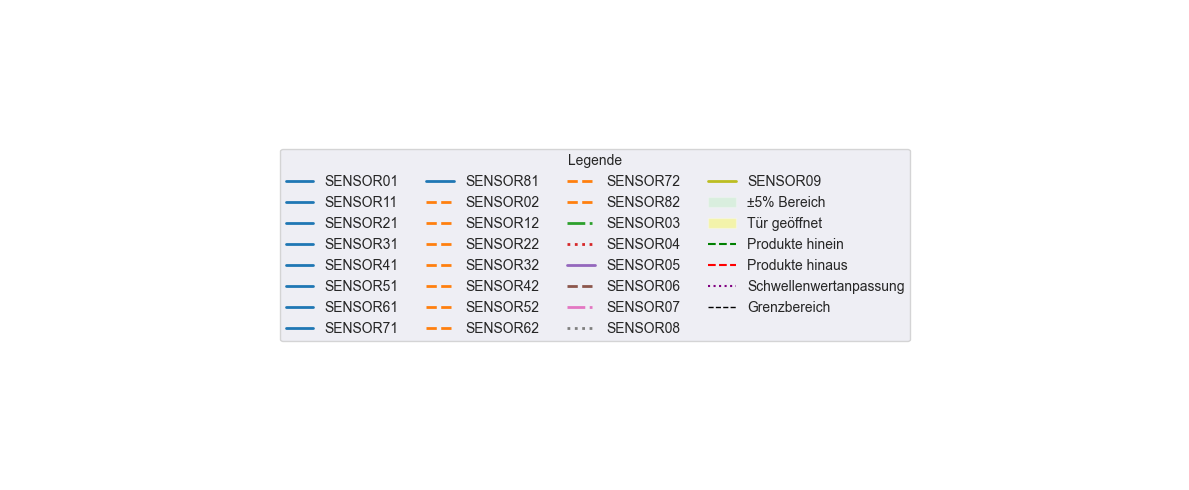

In [17]:



# Sensoren nach deinem Sortierwunsch gruppieren (wie vorher)
s1 = sorted([s for s in sensor_list if s.endswith('1')])
s2 = sorted([s for s in sensor_list if s.endswith('2')])
s_rest = sorted([s for s in sensor_list if not (s.endswith('1') or s.endswith('2'))])
custom_sorted_sensor_list = s1 + s2 + s_rest

# Sensorhandles nach Style wie im Plot!
sensor_handles = []
fb_ls_idx = fb_col_idx = 0
for sensor in custom_sorted_sensor_list:
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1
    handle = Line2D([0], [0], label=sensor, linestyle=style['linestyle'], color=style['color'], linewidth=2)
    sensor_handles.append(handle)

# Event-Handles exakt wie im Hauptplot
event_handles = [
    Patch(facecolor='lightgreen', alpha=0.22, label='±5% Bereich'),
    Patch(facecolor='yellow', alpha=0.3, label='Tür geöffnet'),
    Line2D([0], [0], color='green', linestyle='--', lw=1.5, label='Produkte hinein'),
    Line2D([0], [0], color='red', linestyle='--', lw=1.5, label='Produkte hinaus'),
    Line2D([0], [0], color='purple', linestyle=':', lw=1.5, label='Schwellenwertanpassung'),
    Line2D([0], [0], color='black', linestyle='--', lw=1, label='Grenzbereich')
]

all_handles = sensor_handles + event_handles

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
ax.legend(handles=all_handles, loc='center', fontsize=10, title='Legende', ncol=4)
plt.tight_layout()
plt.show()


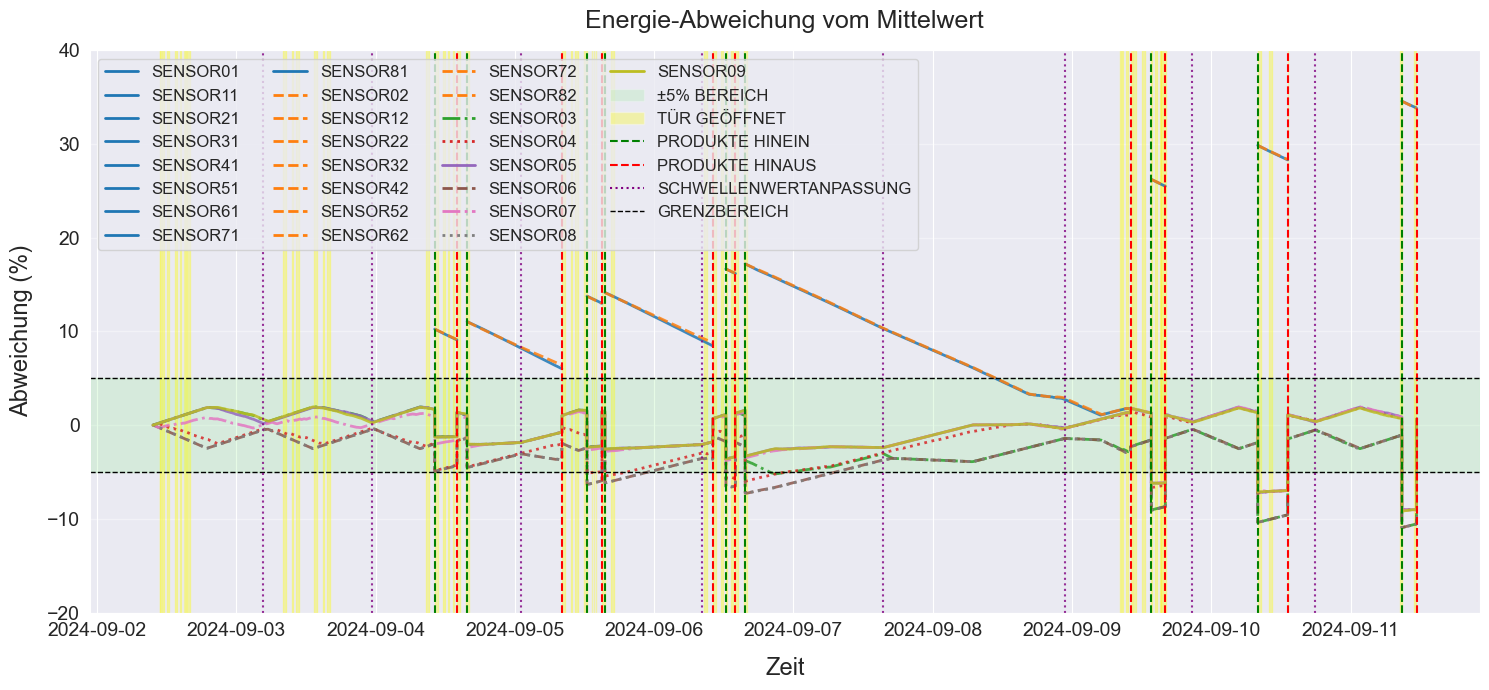

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

# --- 1) Mittelwert und Abweichung berechnen ---
df['Mean Energy'] = df.groupby('Timestamp')['Energy Level'].transform('mean')
df['Deviation']   = df['Energy Level'] - df['Mean Energy']

threshold = 5.0

fig, ax = plt.subplots(figsize=(15, 7))

# --- Grüner Bereich für ±5% ---
ax.axhspan(-threshold, threshold, color='lightgreen', alpha=0.22, label='±5% Bereich')

# --- Gruppendefinitionen für Endziffern ---
group_styles = {
    '1': {'linestyle': '-',  'color': plt.cm.tab10.colors[0]},
    '2': {'linestyle': '--', 'color': plt.cm.tab10.colors[1]}
}
fallback_linestyles = ['-.', ':', '-', '--']
fallback_colors     = plt.cm.tab10.colors[2:]

# --- Sensoren sortieren wie gewünscht ---
custom_sorted_sensor_list = [
    "SENSOR01", "SENSOR11", "SENSOR21", "SENSOR31", "SENSOR41",
    "SENSOR51", "SENSOR61", "SENSOR71", "SENSOR81",
    "SENSOR02", "SENSOR12", "SENSOR22", "SENSOR32", "SENSOR42",
    "SENSOR52", "SENSOR62", "SENSOR72", "SENSOR82",
    "SENSOR03", "SENSOR04", "SENSOR05", "SENSOR06", "SENSOR07", "SENSOR08", "SENSOR09"
]

# --- Sensor-Linestyles wie im Plot ---
sensor_handles = []
fb_ls_idx = fb_col_idx = 0
for sensor in custom_sorted_sensor_list:
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1
    handle = Line2D([0], [0], label=sensor, linestyle=style['linestyle'], color=style['color'], linewidth=2)
    sensor_handles.append(handle)

# --- Alle Sensoren zeichnen (Plot selbst) ---
fb_ls_idx = fb_col_idx = 0
for sensor in custom_sorted_sensor_list:
    sensor_data = df[df['Sensor'] == sensor]
    style = None
    for suffix, props in group_styles.items():
        if sensor.endswith(suffix):
            style = props
            break
    if style is None:
        style = {
            'linestyle': fallback_linestyles[fb_ls_idx % len(fallback_linestyles)],
            'color':     fallback_colors[fb_col_idx % len(fallback_colors)]
        }
        fb_ls_idx += 1
        fb_col_idx += 1

    ax.plot(
        sensor_data['Timestamp'],
        sensor_data['Deviation'],
        label=sensor,
        linestyle=style['linestyle'],
        color=style['color'],
        linewidth=2,
        alpha=0.85
    )

# --- Event-Overlays ---
activity_data = pd.read_csv('experiment_actions.csv', sep=';', header=0)
activity_data['Start'] = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['Start Time'])
activity_data['End']   = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['End Time'])
start_time = df['Timestamp'].min()
end_time   = df['Timestamp'].max()
activity_filtered = activity_data[
    (activity_data['Start'] >= start_time) &
    (activity_data['End']   <= end_time)
]

door_labeled    = False
product_labeled = {'in': False, 'out': False}
current_in_time = None

for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        ax.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.3,
            label='Tür geöffnet' if not door_labeled else ""
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        ax.axvline(
            current_in_time,
            color='green', linestyle='--', linewidth=1.5,
            label='Produkte hinein' if not product_labeled['in'] else ""
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        ax.axvline(
            row['Start'],
            color='red', linestyle='--', linewidth=1.5,
            label='Produkte hinaus' if not product_labeled['out'] else ""
        )
        product_labeled['out'] = True
        current_in_time = None

ax.axhline(threshold, color='black', linestyle='--', linewidth=1, label='Grenzbereich')
ax.axhline(-threshold, color='black', linestyle='--', linewidth=1)

# <--- SCHWELLENWERT-LINIEN HINZUFÜGEN!
plot_threshold_lines_plt(df_thr)   # <-- deine Funktion

# --- Achsentitel, Schriftgröße, und Ausrichtung ---
ax.set_ylabel("Abweichung (%)", fontsize=17, labelpad=10, loc="center")
ax.set_xlabel("Zeit", fontsize=17, labelpad=12)
ax.set_title("Energie-Abweichung vom Mittelwert", fontsize=18, pad=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# --- Grid mit Hauptlinien (jede 10 Einheiten) ---
yticks_major = np.arange(-20, 41, 10)  # z.B. von -20 bis 40 in 10er Schritten, anpassen je nach Bereich!
ax.set_yticks(yticks_major)
ax.grid(True, which='major', axis='y', linestyle='-', linewidth=1, alpha=0.4)

# === KOMPLETTE LEGENDE ===
event_handles = [
    Patch(facecolor='lightgreen', alpha=0.22, label='±5% BEREICH'),
    Patch(facecolor='yellow', alpha=0.3, label='TÜR GEÖFFNET'),
    Line2D([0], [0], color='green', linestyle='--', lw=1.5, label='PRODUKTE HINEIN'),
    Line2D([0], [0], color='red', linestyle='--', lw=1.5, label='PRODUKTE HINAUS'),
    Line2D([0], [0], color='purple', linestyle=':', lw=1.5, label='SCHWELLENWERTANPASSUNG'),
    Line2D([0], [0], color='black', linestyle='--', lw=1, label='GRENZBEREICH')
]

all_handles = sensor_handles + event_handles
all_labels  = [h.get_label() for h in sensor_handles] + [h.get_label() for h in event_handles]

ax.legend(
    handles=all_handles,
    labels=all_labels,
    loc='upper left',
    fontsize=12,
    ncol=4,
)

plt.tight_layout()
plt.show()


# activ/passiv Diagramm

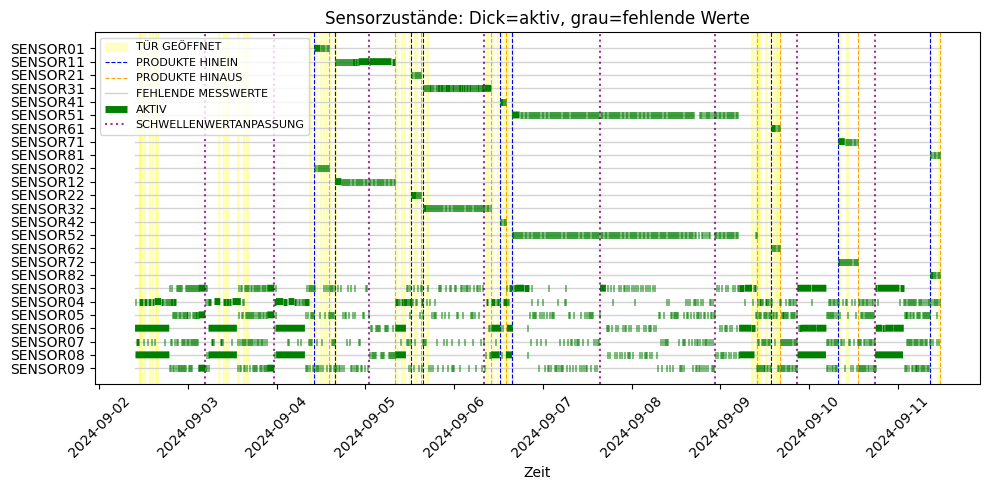

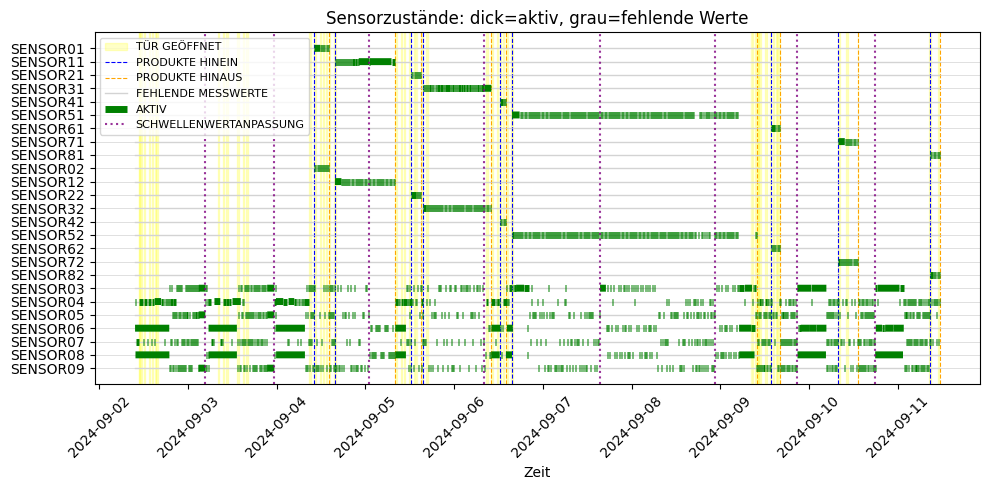

In [42]:


# ----- Hilfsfunktion für die gewünschte Sensor-Sortierung -----
def custom_sensor_sort(sensor_name):
    # Extrahiere Endziffer
    if isinstance(sensor_name, str) and sensor_name[-1].isdigit():
        last_digit = int(sensor_name[-1])
    else:
        last_digit = -1

    # Sensor-Gruppen in der Reihenfolge: 1er → 2er → 3–9er
    if last_digit == 1:
        group = 0
    elif last_digit == 2:
        group = 1
    elif last_digit in range(3, 10):
        group = 2
    else:
        group = 3

    # Innerhalb der Gruppe nach Zahl im Namen sortieren (z.B. 01, 11, 21…)
    num = int(sensor_name[-2:]) if sensor_name[-2:].isdigit() else 999
    return (group, num)

sensor_list = sorted(df['Sensor'].unique(), key=custom_sensor_sort)[::-1]  # umgedreht


# --- State-Map NUR grün für "active" ---
state_map = {
    'active':  {'color': 'green', 'lw': 5, 'ls': '-'}
}

fig, ax = plt.subplots(figsize=(10, 5))

# 1) Ereignisse laden und filtern
activity_data = pd.read_csv('experiment_actions.csv', sep=';', header=0)
activity_data['Start'] = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['Start Time'])
activity_data['End']   = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['End Time'])
start_time = df['Timestamp'].min()
end_time   = df['Timestamp'].max()
activity_filtered = activity_data[
    (activity_data['Start'] >= start_time) & (activity_data['End'] <= end_time)
]

# 2) Hintergrund-Events einzeichnen (nur DEUTSCHE Labels)
door_labeled = False
product_labeled = {'in': False, 'out': False}
current_in_time = None

for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        ax.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.22,
            label='Tür geöffnet' if not door_labeled else "",
            zorder=0
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        ax.axvline(
            current_in_time,
            color='blue', linestyle='--', linewidth=0.8,
            label='Produkte hinein' if not product_labeled['in'] else "",
            zorder=1
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        ax.axvline(
            row['Start'],
            color='orange', linestyle='--', linewidth=0.8,
            label='Produkte hinaus' if not product_labeled['out'] else "",
            zorder=1
        )
        product_labeled['out'] = True
        current_in_time = None

# 3) Graue Baseline pro Sensor für fehlende Werte
for i, sensor in enumerate(sensor_list):
    ax.plot([df['Timestamp'].min(), df['Timestamp'].max()],
            [i, i],
            color='lightgrey', linewidth=1, zorder=0,
            label='Fehlende Messwerte' if i == 0 else "")

# 4) Nur AKTIVE Zustände zeichnen (grün), KEINE passiven!
for i, sensor in enumerate(sensor_list):
    d = df[df['Sensor'] == sensor].sort_values('Timestamp')
    states = d['State'].values
    times  = d['Timestamp'].values
    if len(times) < 2:
        continue
    segments = []
    last_idx = 0
    for idx in range(1, len(d)):
        if states[idx] != states[idx-1]:
            segments.append((last_idx, idx-1))
            last_idx = idx
    segments.append((last_idx, len(d)-1))
    for start, end in segments:
        state = states[start]
        if state != 'active':
            continue  # NUR active zeichnen!
        ax.plot(times[start:end+1],
                [i] * (end - start + 1),
                color=state_map[state]['color'],
                lw=state_map[state]['lw'],
                linestyle=state_map[state]['ls'],
                solid_capstyle='butt',
                zorder=2,
                label='AKTIV' if i == 0 else None
        )

# Y-Ticks und Labels
ax.set_yticks(range(len(sensor_list)))
ax.set_yticklabels(sensor_list)
ax.set_xlabel("Zeit")
ax.set_title("Sensorzustände: Dick=aktiv, grau=fehlende Werte")

plt.xticks(rotation=45)

# Optional: Schwellenwert-Linien einzeichnen, falls gewünscht
try:
    plot_threshold_lines_plt(df_thr)
except Exception:
    pass

# Legende auf Deutsch, doppelte entfernen und alles in CAPS
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))   # Original-Labels, keine CAPS
ax.legend(
    by_label.values(),
    [label.upper() for label in by_label.keys()],   # <-- HIER: alles in Großbuchstaben
    loc='upper left',
    fontsize=8
)


plt.tight_layout()
plt.style.use('default')  # heller Standard-Stil
# oder noch expliziter:
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

plt.savefig("ansatz_1_humidity_mean", dpi=300)  # <-- speichert als PNG
plt.show()

# ----- Hilfsfunktion für die gewünschte Sensor-Sortierung -----
def custom_sensor_sort(sensor_name):
    # Extrahiere Endziffer
    if isinstance(sensor_name, str) and sensor_name[-1].isdigit():
        last_digit = int(sensor_name[-1])
    else:
        last_digit = -1

    # Sensor-Gruppen in der Reihenfolge: 1er → 2er → 3–9er
    if last_digit == 1:
        group = 0
    elif last_digit == 2:
        group = 1
    elif last_digit in range(3, 10):
        group = 2
    else:
        group = 3

    # Innerhalb der Gruppe nach Zahl im Namen sortieren (z.B. 01, 11, 21…)
    num = int(sensor_name[-2:]) if sensor_name[-2:].isdigit() else 999
    return (group, num)

sensor_list = sorted(df['Sensor'].unique(), key=custom_sensor_sort)[::-1]  # umgedreht


# --- State-Map NUR grün für "active" ---
state_map = {
    'active':  {'color': 'green', 'lw': 5, 'ls': '-'}
}

fig, ax = plt.subplots(figsize=(10, 5))

# 1) Ereignisse laden und filtern
activity_data = pd.read_csv('experiment_actions.csv', sep=';', header=0)
activity_data['Start'] = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['Start Time'])
activity_data['End']   = pd.to_datetime(activity_data['Date'] + ' ' + activity_data['End Time'])
start_time = df['Timestamp'].min()
end_time   = df['Timestamp'].max()
activity_filtered = activity_data[
    (activity_data['Start'] >= start_time) & (activity_data['End'] <= end_time)
]

# 2) Hintergrund-Events einzeichnen (nur DEUTSCHE Labels)
door_labeled = False
product_labeled = {'in': False, 'out': False}
current_in_time = None

for _, row in activity_filtered.iterrows():
    action = row['Action'].lower()
    if 'door opened' in action:
        ax.axvspan(
            row['Start'], row['End'],
            color='yellow', alpha=0.22,
            label='Tür geöffnet' if not door_labeled else "",
            zorder=0
        )
        door_labeled = True
    if 'products in' in action:
        current_in_time = row['Start']
        ax.axvline(
            current_in_time,
            color='blue', linestyle='--', linewidth=0.8,
            label='Produkte hinein' if not product_labeled['in'] else "",
            zorder=1
        )
        product_labeled['in'] = True
    elif 'products out' in action and current_in_time is not None:
        ax.axvline(
            row['Start'],
            color='orange', linestyle='--', linewidth=0.8,
            label='Produkte hinaus' if not product_labeled['out'] else "",
            zorder=1
        )
        product_labeled['out'] = True
        current_in_time = None

# 3) Graue Baseline pro Sensor für fehlende Werte
for i, sensor in enumerate(sensor_list):
    ax.plot([df['Timestamp'].min(), df['Timestamp'].max()],
            [i, i],
            color='lightgrey', linewidth=1, zorder=0,
            label='Fehlende Messwerte' if i == 0 else "")

# 4) Nur AKTIVE Zustände zeichnen (grün), KEINE passiven!
for i, sensor in enumerate(sensor_list):
    d = df[df['Sensor'] == sensor].sort_values('Timestamp')
    states = d['State'].values
    times  = d['Timestamp'].values
    if len(times) < 2:
        continue
    segments = []
    last_idx = 0
    for idx in range(1, len(d)):
        if states[idx] != states[idx-1]:
            segments.append((last_idx, idx-1))
            last_idx = idx
    segments.append((last_idx, len(d)-1))
    for start, end in segments:
        state = states[start]
        if state != 'active':
            continue  # NUR active zeichnen!
        ax.plot(times[start:end+1],
                [i] * (end - start + 1),
                color=state_map[state]['color'],
                lw=state_map[state]['lw'],
                linestyle=state_map[state]['ls'],
                solid_capstyle='butt',
                zorder=2,
                label='AKTIV' if i == 0 else None
        )

# Y-Ticks und Labels
ax.set_yticks(range(len(sensor_list)))
ax.set_yticklabels(sensor_list)
ax.set_xlabel("Zeit")
ax.set_title("Sensorzustände: dick=aktiv, grau=fehlende Werte")
# >>> Grid-Einstellungen HIER einfügen <<<
ax.grid(False)  # alles aus
ax.grid(axis='y', color='lightgrey', linestyle='-', linewidth=0.5)  # nur horizontale

plt.xticks(rotation=45)

# Optional: Schwellenwert-Linien einzeichnen, falls gewünscht
try:
    plot_threshold_lines_plt(df_thr)
except Exception:
    pass

# Legende auf Deutsch, doppelte entfernen und alles in CAPS
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))   # Original-Labels, keine CAPS
ax.legend(
    by_label.values(),
    [label.upper() for label in by_label.keys()],   # <-- HIER: alles in Großbuchstaben
    loc='upper left',
    fontsize=8
)


plt.tight_layout()
plt.style.use('default')  # heller Standard-Stil
# oder noch expliziter:
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

plt.savefig("ansatz_1_temperature_mean", dpi=300)  # <-- speichert als PNG
plt.show()





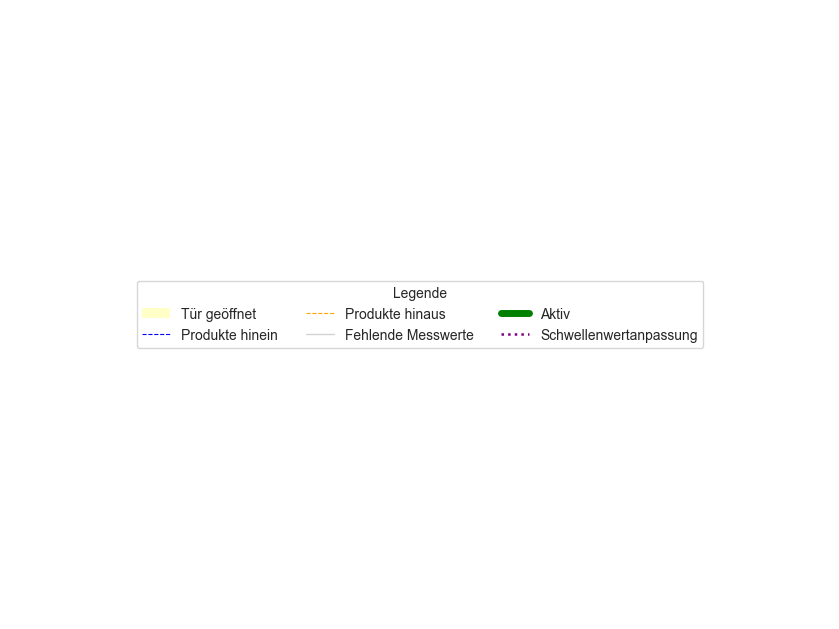

In [20]:


legend_elements = [
    Patch(facecolor='yellow', alpha=0.22, edgecolor='none', label='Tür geöffnet'),
    Line2D([0], [0], color='blue', linestyle='--', linewidth=0.8, label='Produkte hinein'),
    Line2D([0], [0], color='orange', linestyle='--', linewidth=0.8, label='Produkte hinaus'),
    Line2D([0], [0], color='lightgrey', linewidth=1, label='Fehlende Messwerte'),
    Line2D([0], [0], color='green', linewidth=5, label='Aktiv'),
    Line2D([0], [0], color='purple', linestyle=':', linewidth=1.8, label='Schwellenwertanpassung'),
]

fig_legend = plt.figure(figsize=(8.5, 6.4))
fig_legend.legend(
    handles=legend_elements,
    loc='center',
    title='Legende',
    frameon=True,
    ncol=3   # <--- Drei Spalten!
)
plt.axis('off')
plt.tight_layout()
plt.show()


#    ################################
#  5. Zahl der Schritte jeder Sensor war aktiv
#   ################################

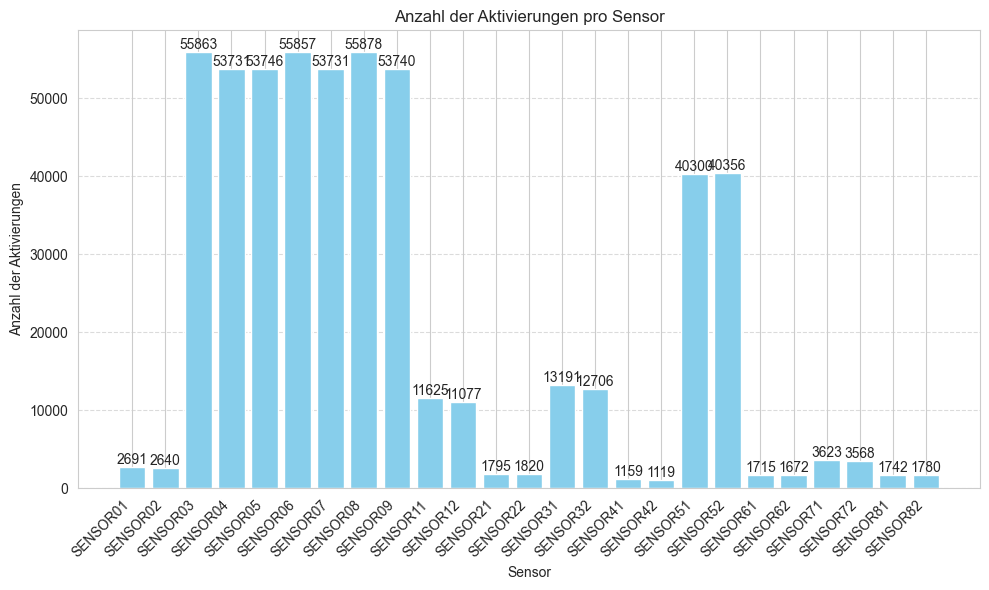

In [21]:



# Count only when State is 'active'
active_counts = df[df['State'] == 'active']['Sensor'].value_counts().sort_index()

# Optional: sort by sensor order if needed
sensor_order = sorted(active_counts.index, key=lambda x: int(x.replace('SENSOR', '')))
active_counts = active_counts.reindex(sensor_order)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(active_counts.index, active_counts.values, color='skyblue')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             str(int(height)), ha='center', va='bottom')

# Drehe die Sensorennamen um 45°
plt.xticks(rotation=45, ha='right')

plt.title("Anzahl der Aktivierungen pro Sensor")
plt.xlabel("Sensor")
plt.ylabel("Anzahl der Aktivierungen")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#    ################################
#  6. Für jeden Sensor den Anteil der Zeit, in der er im Zustand active war – also seinen „Duty Cycle“:
#   ################################

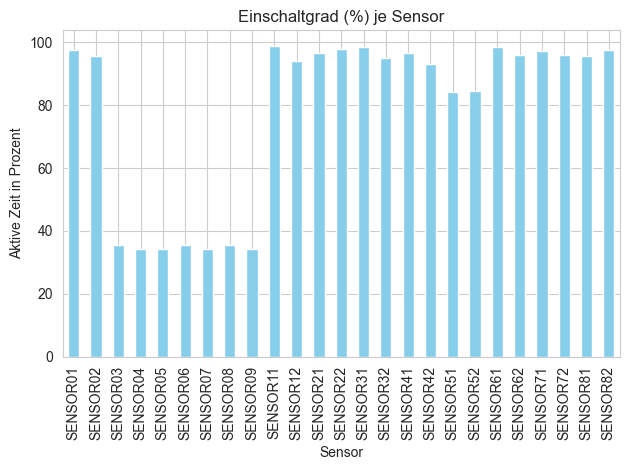

In [22]:
# Gesamtzahl der Messungen pro Sensor
total = df.groupby("Sensor")['State'].count()

# Anzahl der aktiven Messungen pro Sensor
active = df[df['State'] == 'active'].groupby("Sensor")['State'].count()

# Prozentualer Anteil (Einschaltgrad)
duty_cycle = (active / total * 100).sort_index()

# Balkendiagramm mit deutschen Beschriftungen und Titel
ax = duty_cycle.plot(
    kind='bar',
    color='skyblue',
    title='Einschaltgrad (%) je Sensor'
)
ax.set_ylabel("Aktive Zeit in Prozent")
ax.set_xlabel("Sensor")
ax.grid(True)
plt.tight_layout()
plt.show()


# 6.1. Basierend auf der Anzahl der Schritte ein Sensor insgesamt nicht im %

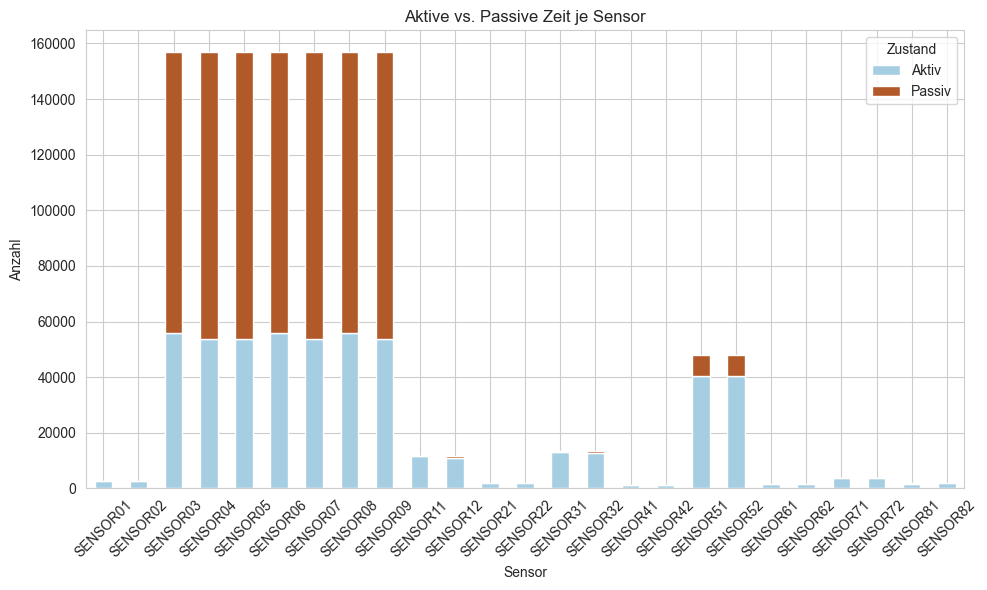

In [23]:
# Anzahl aktiver/passiver Zustände pro Sensor zählen
state_counts = df.groupby(["Sensor", "State"]).size().unstack(fill_value=0)

# Gestapeltes Balkendiagramm
ax = state_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="Paired"
)
plt.title("Aktive vs. Passive Zeit je Sensor")
plt.xlabel("Sensor")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.legend(title="Zustand", labels=["Aktiv", "Passiv"])  # Reihenfolge ggf. prüfen!
plt.tight_layout()
plt.show()


# 7.1 Basierend auf der Anzahl der Schritte des Simulationslaufes

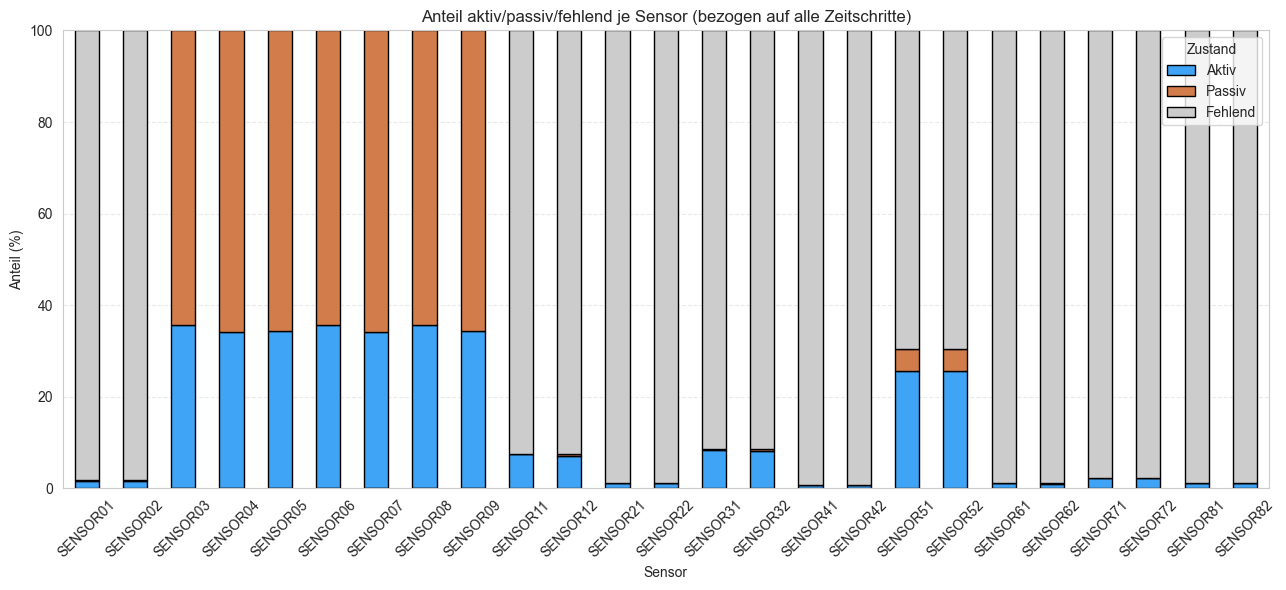

In [24]:

# 1) Alle Zeitstempel und Sensoren-Kombinationen
all_times = pd.Series(df['Timestamp'].unique()).sort_values()
all_sensors = sorted(df['Sensor'].unique())

# 2) Leeres DataFrame (alle Kombinationen von Sensor & Zeit)
index = pd.MultiIndex.from_product([all_sensors, all_times], names=["Sensor", "Timestamp"])
df_full = pd.DataFrame(index=index).reset_index()

# 3) Merge mit deinen Daten
df_merge = df_full.merge(df[['Sensor', 'Timestamp', 'State']], how='left', on=['Sensor', 'Timestamp'])

# 4) States codieren: active, passive, missing
def get_state(s):
    if pd.isna(s):
        return 'missing'
    return s

df_merge['FinalState'] = df_merge['State'].apply(get_state)

# 5) Zählen pro Sensor
state_counts = df_merge.groupby(['Sensor', 'FinalState']).size().unstack(fill_value=0)

# 6) Immer alle drei Spalten haben
for col in ['active', 'passive', 'missing']:
    if col not in state_counts.columns:
        state_counts[col] = 0
state_counts = state_counts[['active', 'passive', 'missing']]

# 7) In Prozent umrechnen (alle Schritte insgesamt)
percent = state_counts.div(state_counts.sum(axis=1), axis=0) * 100

# 8) Plot
colors = ["#3fa4f5", "#d17c4a", "#cccccc"]  # active=blau, passive=braun, missing=grau
labels_de = ["Aktiv", "Passiv", "Fehlend"]

ax = percent.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=colors,
    edgecolor="black"
)
plt.title("Anteil aktiv/passiv/fehlend je Sensor (bezogen auf alle Zeitschritte)")
plt.xlabel("Sensor")
plt.ylabel("Anteil (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
ax.legend(labels_de, title="Zustand", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# 7.2 Basierend auf der Anzahl der Schritte ein Sensor existierte

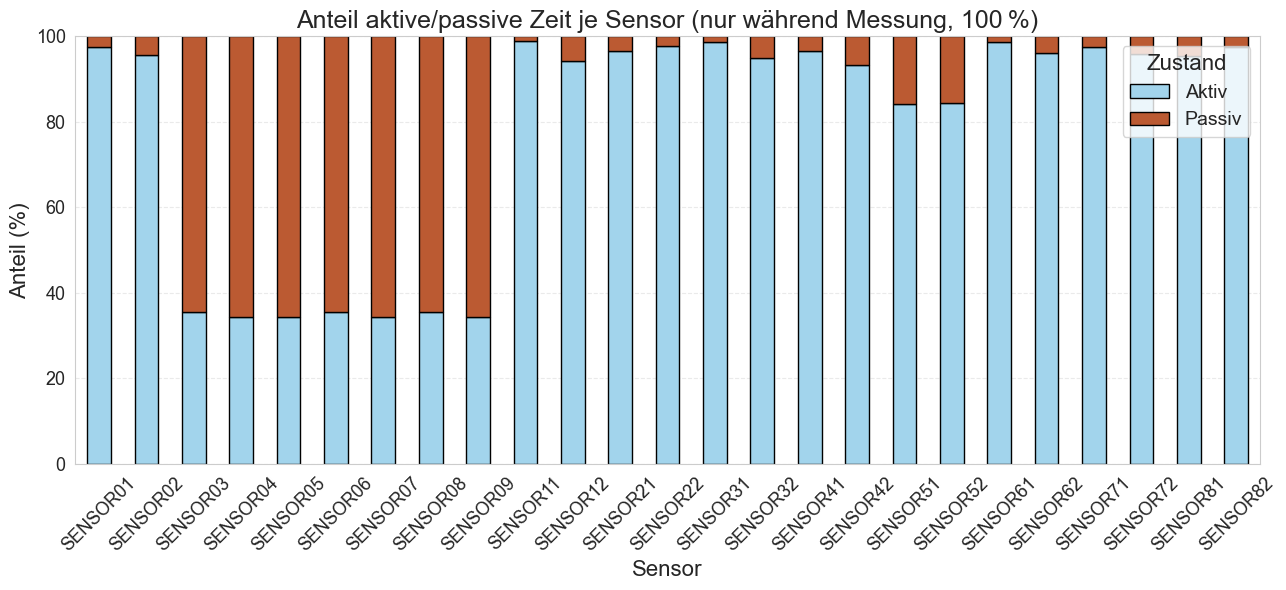

In [25]:

# 1) Prozentwerte pro Sensor (nur vorhandene Werte)
state_counts = df.groupby(["Sensor", "State"]).size().unstack(fill_value=0)
# Sicherstellen, dass beide Spalten existieren
for state in ["active", "passive"]:
    if state not in state_counts.columns:
        state_counts[state] = 0
state_counts = state_counts[["active", "passive"]]  # richtige Reihenfolge

# Prozentuale Anteile berechnen
percent = state_counts.div(state_counts.sum(axis=1), axis=0).fillna(0) * 100

# 2) Plot als Prozent-Balken
ax = percent.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=["#a2d4ec", "#bb5a32"],  # blau für aktiv, braun für passiv
    edgecolor="black"
)
# ... dein vorheriger Code bleibt unverändert ...

plt.title("Anteil aktive/passive Zeit je Sensor (nur während Messung, 100 %)", fontsize=18)     # Titelgröße z.B. 18
plt.xlabel("Sensor", fontsize=16)        # X-Achse größer
plt.ylabel("Anteil (%)", fontsize=16)    # Y-Achse größer
plt.ylim(0, 100)
plt.xticks(rotation=45, fontsize=13)     # Optional: x-Ticks größer
plt.yticks(fontsize=13)                  # Optional: y-Ticks größer

# Legende auf Deutsch sortieren
handles, labels = ax.get_legend_handles_labels()
label_map = {"active": "Aktiv", "passive": "Passiv"}
order = [labels.index('active'), labels.index('passive')]
ax.legend(
    [handles[i] for i in order],
    [label_map[labels[i]] for i in order],
    title="Zustand",
    loc="upper right",
    fontsize=14,          # <-- Legendentext größer
    title_fontsize=16     # <-- Legendentitel noch größer
)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig("sensor_zeitanteil.jpg", dpi=300, format='jpeg')

plt.show()



#    ################################
#  8. Durchschnittsenergie und Schwellenwerte einlesen und zeigen
#   ################################

In [26]:

# 1) Pfad zur Logdatei anpassen
log_path = 'sim_structural.log'

# 2) Alle relevanten Zeilen einlesen
entries = []
with open(log_path, 'r', encoding='utf-8') as f:
    for line in f:
        if 'Lowering rel_thr' in line:
            entries.append(line.strip())

# 3) Mit Regex parsen
pattern = re.compile(
    r'\[(?P<sim_time>\d{2}\.\d{2}\.\d{4} \d{2}:\d{2}:\d{2})\]\s+Lowering rel_thr\s+'
    r'(?P<old>[0-9.]+)→(?P<new>[0-9.]+)'
)
records = []
for line in entries:
    m = pattern.search(line)
    if m:
        sim_time = pd.to_datetime(m.group('sim_time'), format='%d.%m.%Y %H:%M:%S')
        old_thr = float(m.group('old'))
        new_thr = float(m.group('new'))
        records.append((sim_time, old_thr, new_thr))

# 4) DataFrame bauen
df_thr = pd.DataFrame(records,
    columns=['Simulationszeit', 'Alter Schwellenwert', 'Neuer Schwellenwert']
)



# 5) cut the dataframe till 19 Line 
# nach dem Erzeugen von df_thr
df_thr = df_thr.head(40)   # behält nur Zeilen 0–18


print(df_thr)

      Simulationszeit  Alter Schwellenwert  Neuer Schwellenwert
0 2024-09-03 04:39:05                 0.95                 0.90
1 2024-09-03 23:20:20                 0.90                 0.85
2 2024-09-05 01:04:55                 0.85                 0.80
3 2024-09-06 08:12:25                 0.80                 0.75
4 2024-09-07 15:29:00                 0.75                 0.70
5 2024-09-08 22:42:25                 0.70                 0.65
6 2024-09-09 20:41:20                 0.65                 0.60
7 2024-09-10 17:53:40                 0.60                 0.55


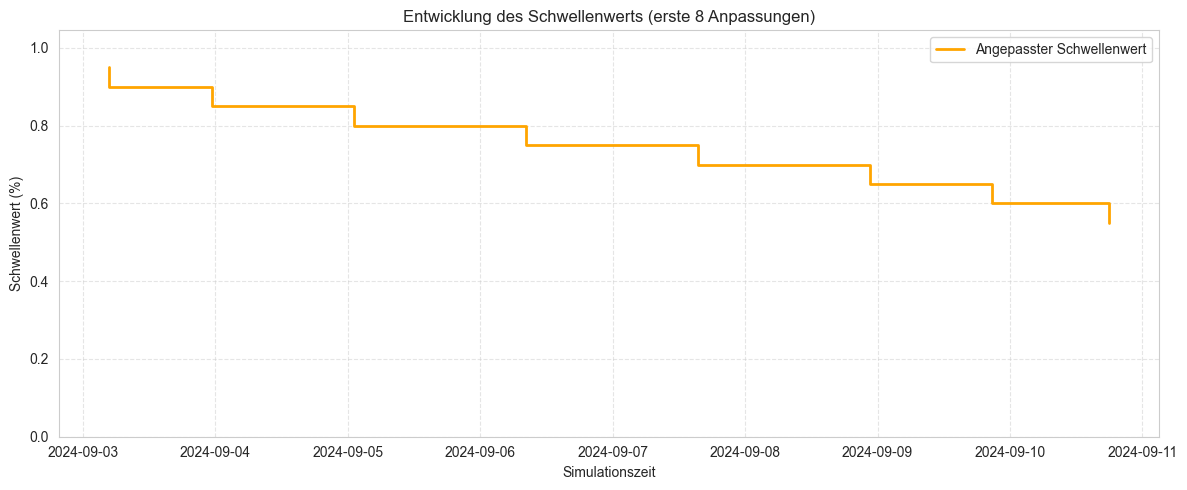

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1) Logdatei parsen
log_path = 'sim_structural.log'

entries = []
with open(log_path, 'r', encoding='utf-8') as f:
    for line in f:
        if 'Lowering rel_thr' in line:
            entries.append(line.strip())

pattern = re.compile(
    r'\[(?P<sim_time>\d{2}\.\d{2}\.\d{4} \d{2}:\d{2}:\d{2})\]\s+Lowering rel_thr\s+'
    r'(?P<old>[0-9.]+)→(?P<new>[0-9.]+)'
)
records = []
for line in entries:
    m = pattern.search(line)
    if m:
        sim_time = pd.to_datetime(m.group('sim_time'), format='%d.%m.%Y %H:%M:%S')
        old_thr = float(m.group('old'))
        new_thr = float(m.group('new'))
        records.append((sim_time, old_thr, new_thr))

df_thr = pd.DataFrame(records,
    columns=['Simulationszeit', 'Alter Schwellenwert', 'Neuer Schwellenwert']
)

df_plot = df_thr.iloc[0:9].copy()

# 3) Treppenplot-Vektoren bauen
start_time = df_plot.iloc[0]['Simulationszeit']
start_value = df_plot.iloc[0]['Alter Schwellenwert']

x_vals = [start_time]
y_vals = [start_value]

for i, row in df_plot.iterrows():
    x_vals.append(row['Simulationszeit'])
    y_vals.append(row['Neuer Schwellenwert'])

# 4) Plot
plt.figure(figsize=(12, 5))
plt.step(x_vals, y_vals, where='post', label='Angepasster Schwellenwert', color='orange', linewidth=2)
plt.xlabel('Simulationszeit')
plt.ylabel('Schwellenwert (%)')
plt.title('Entwicklung des Schwellenwerts (erste 8 Anpassungen)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, max(y_vals) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()


#    ################################
#  9. Schwellenwertanpassung Zeitraum 
#   ################################

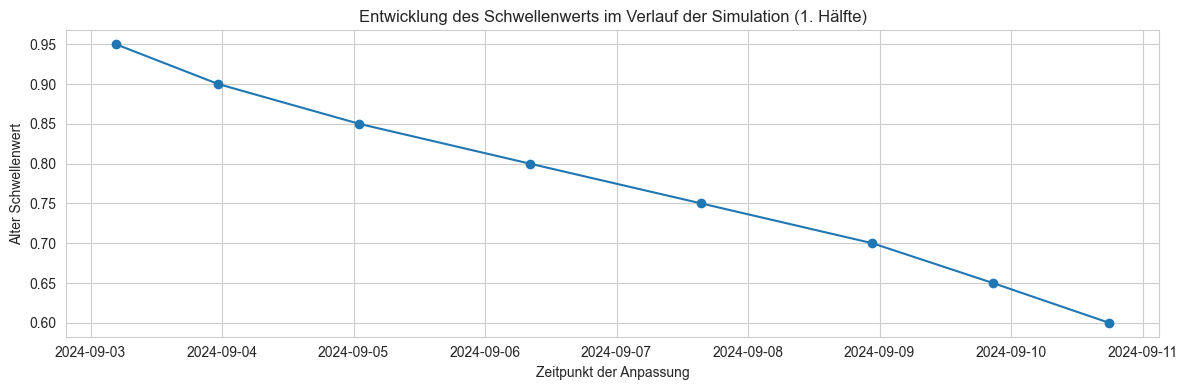

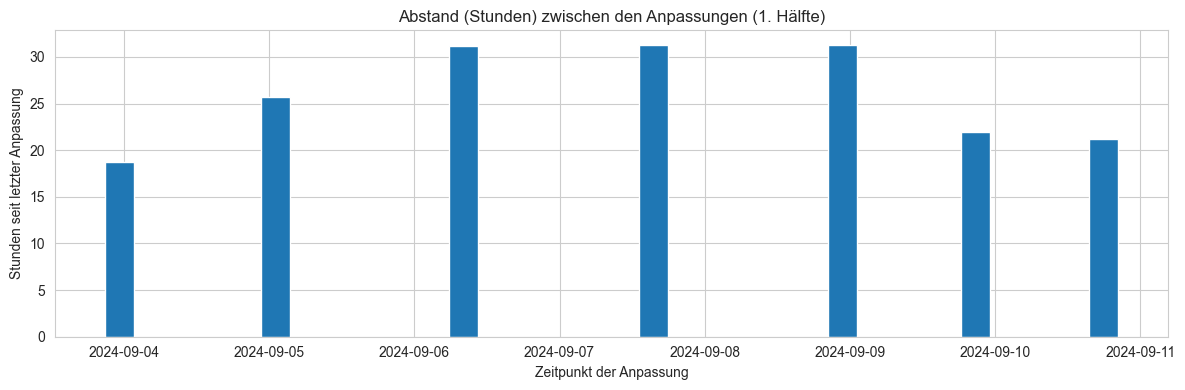

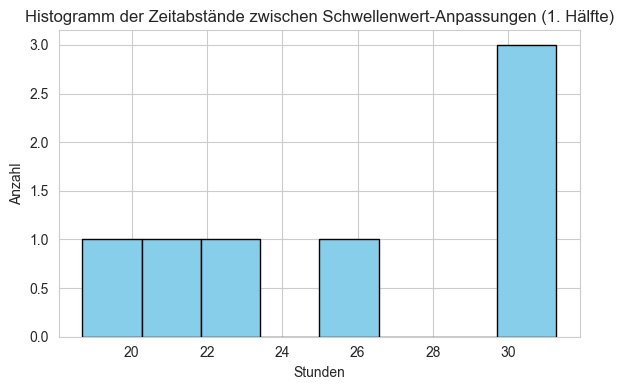

In [28]:
# Wir nehmen an, df_thr ist bereits wie gezeigt gebaut und sortiert

# 1. Nur die ersten 9 Anpassungen (Index 0 bis 8, insgesamt 9 Stück)
df_thr_slice = df_thr.iloc[0:9].copy()

# 1. Plot: Verlauf des "Alten Schwellenwerts" über die Zeit (nur Slice!)
plt.figure(figsize=(12,4))
plt.plot(df_thr_slice['Simulationszeit'], df_thr_slice['Alter Schwellenwert'], marker='o')
plt.title('Entwicklung des Schwellenwerts im Verlauf der Simulation (1. Hälfte)')
plt.xlabel('Zeitpunkt der Anpassung')
plt.ylabel('Alter Schwellenwert')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Abstand (in Stunden) zwischen den Anpassungen im Slice
df_thr_slice['Delta_h'] = df_thr_slice['Simulationszeit'].diff().dt.total_seconds() / 3600

plt.figure(figsize=(12,4))
plt.bar(df_thr_slice['Simulationszeit'].iloc[1:], df_thr_slice['Delta_h'].iloc[1:], width=0.2)
plt.title('Abstand (Stunden) zwischen den Anpassungen (1. Hälfte)')
plt.xlabel('Zeitpunkt der Anpassung')
plt.ylabel('Stunden seit letzter Anpassung')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Optional: Histogramm der Zeitabstände (nur Slice)
plt.figure(figsize=(6,4))
plt.hist(df_thr_slice['Delta_h'].dropna(), bins=8, color='skyblue', edgecolor='k')
plt.title('Histogramm der Zeitabstände zwischen Schwellenwert-Anpassungen (1. Hälfte)')
plt.xlabel('Stunden')
plt.ylabel('Anzahl')
plt.tight_layout()
plt.show()


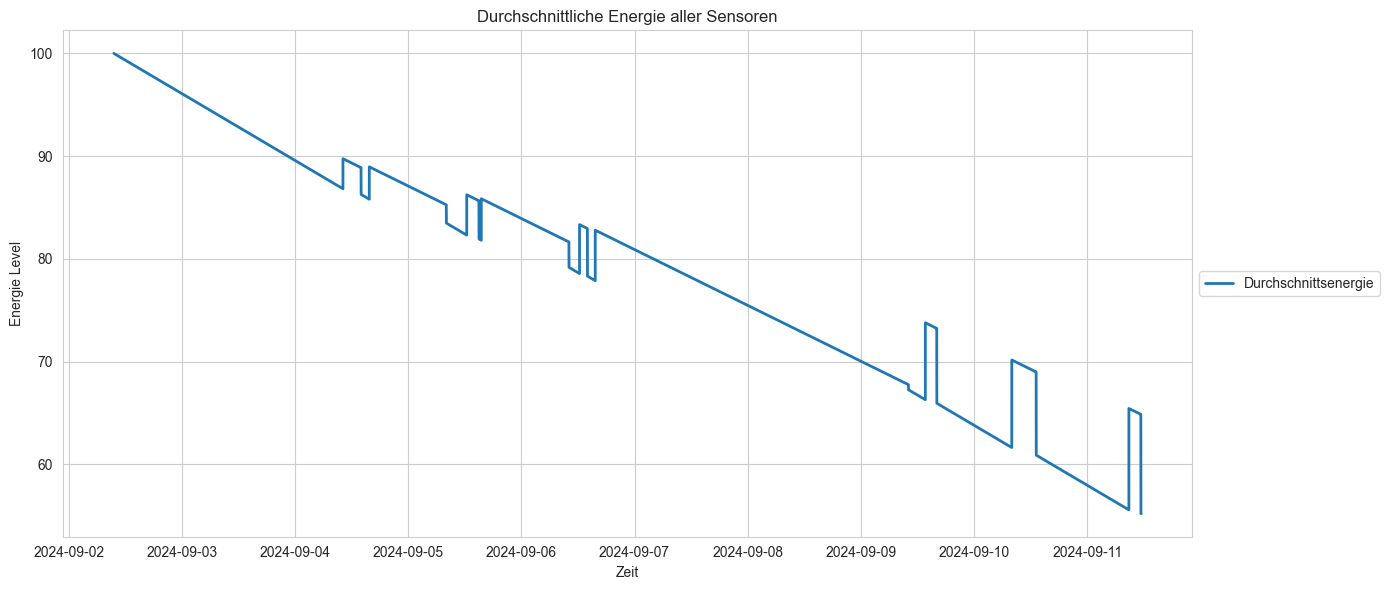

In [29]:
#########################################
# # Daten laden
# df = pd.read_csv("whole_sensor_data.csv", sep=";")

# # Kombiniere Datum und Uhrzeit zu einem Zeitstempel
# df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Zeitstempel kombinieren 
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d.%m.%Y %H:%M:%S')

# Durchschnittsenergie über alle Sensoren pro Zeitstempel berechnen
durchschn_energy = df.groupby('Timestamp')['Energy Level'].mean()

plt.figure(figsize=(14,6))
plt.plot(
    durchschn_energy.index,
    durchschn_energy.values,
    label='Durchschnittsenergie',
    color='tab:blue',
    linewidth=2
)

plt.xlabel('Zeit')
plt.ylabel('Energie Level')
plt.title('Durchschnittliche Energie aller Sensoren')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


#    ################################
#  9. Wie oft war jeden Sensor im finallen aktiven Set
#   ################################

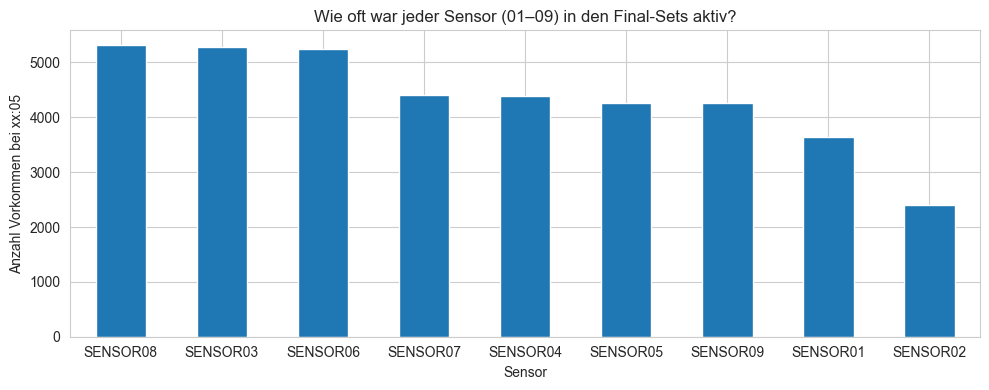

In [30]:


# Hilfsfunktion zum „Normalisieren“ der Sensor-ID:
def normalize_sensor(name: str) -> str:
    """
    Wandelt z.B. 'SENSOR01','SENSOR11','SENSOR21',... → 'SENSOR01'
    analog für alle Endungen 2→'02',…9→'09'.
    """
    m = re.match(r'^(\D+?)(\d+)$', name)
    if not m:
        return name
    prefix, num = m.groups()
    suffix = int(num) % 10
    return f"{prefix}{suffix:02d}"

# 1) Log-Datei einlesen und Final-Sets extrahieren
sets = []  # Liste von Tuplen (Zeitpunkt, tuple_of_sensors)
pattern = re.compile(
    r'\[(?P<time>\d{2}:\d{2}:\d{2})\]\s*Final active set:\s*\[(?P<sensors>[^\]]+)\]'
)

with open('sim_structural.log', 'r') as f:
    for line in f:
        m = pattern.search(line)
        if not m:
            continue
        # nur xx:xx:05
        t = pd.to_datetime(m.group('time'), format='%H:%M:%S')
        if t.second != 5:
            continue

        # Sensor-Strings splitten, strippen und normalisieren
        raw = m.group('sensors')
        sensor_list = []
        for token in raw.split(','):
            tok = token.strip().strip("'\"\\ ")
            sensor_list.append(normalize_sensor(tok))

        # in sortierter Reihenfolge speichern
        sensor_list_sorted = tuple(sorted(sensor_list))
        sets.append(sensor_list_sorted)

if not sets:
    raise RuntimeError("Keine Final active set-Einträge bei xx:05 gefunden.")

# 2) Häufigkeiten zählen
flat = [sensor for s in sets for sensor in s]
sensor_counts = Counter(flat)
set_counts    = Counter(sets)

# 3) In DataFrames überführen
df_sensors = (
    pd.DataFrame.from_dict(sensor_counts, orient='index', columns=['count'])
      .rename_axis('Sensor')
      .sort_values('count', ascending=False)
)

df_sets = (
    pd.DataFrame.from_dict(
        {', '.join(k): v for k,v in set_counts.items()},
        orient='index', columns=['count']
    )
      .rename_axis('Aktives Set')
      .sort_values('count', ascending=False)
)

# 4) Bar-Plot pro Sensor
plt.figure(figsize=(10,4))
df_sensors['count'].plot(kind='bar')
plt.title('Wie oft war jeder Sensor (01–09) in den Final-Sets aktiv?')
plt.ylabel('Anzahl Vorkommen bei xx:05')
plt.xlabel('Sensor')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


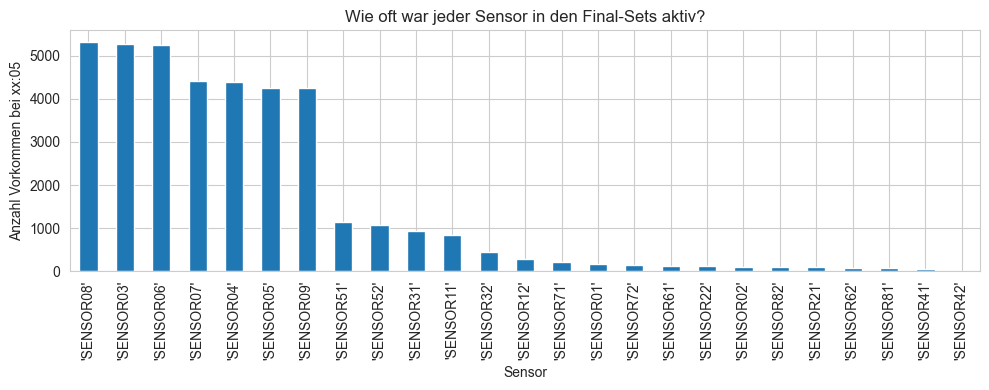

In [31]:

# 1) Log-Datei einlesen und Final-Sets extrahieren
sets = []  # Liste von Tupeln (timestamp, tuple_of_sensors)
pattern = re.compile(r'\[(?P<time>\d{2}:\d{2}:\d{2})\] Final active set: \[(?P<sensors>[^\]]+)\]')

with open('sim_structural.log', 'r') as f:
    for line in f:
        m = pattern.search(line)
        if not m:
            continue
        t = pd.to_datetime(m.group('time'), format='%H:%M:%S')
        if t.second != 5:
            continue
        sensor_list = [s.strip() for s in m.group('sensors').split(',')]
        # Normiere Reihenfolge, damit Sets vergleichbar sind
        sensor_list_sorted = tuple(sorted(sensor_list))
        sets.append(sensor_list_sorted)

if not sets:
    raise RuntimeError("Keine Final active set-Einträge bei xx:05 gefunden.")

# 2) Zähle Häufigkeiten
# a) Sensor-Häufigkeit (explode aller Sets)
flat = [sensor for s in sets for sensor in s]
sensor_counts = Counter(flat)

# b) Set-Häufigkeiten
set_counts = Counter(sets)

# 3) In DataFrames überführen (optional)
df_sensors = pd.DataFrame.from_dict(sensor_counts, orient='index', columns=['count'])
df_sensors.index.name = 'Sensor'
df_sensors = df_sensors.sort_values('count', ascending=False)

df_sets = pd.DataFrame.from_dict(
    {', '.join(k): v for k,v in set_counts.items()},
    orient='index', columns=['count']
)
df_sets.index.name = 'Aktives Set'
df_sets = df_sets.sort_values('count', ascending=False)

# 4) Plotten
plt.figure(figsize=(10,4))
df_sensors['count'].plot(kind='bar')
plt.title('Wie oft war jeder Sensor in den Final-Sets aktiv?')
plt.ylabel('Anzahl Vorkommen bei xx:05')
plt.xlabel('Sensor')
plt.tight_layout()
plt.show()




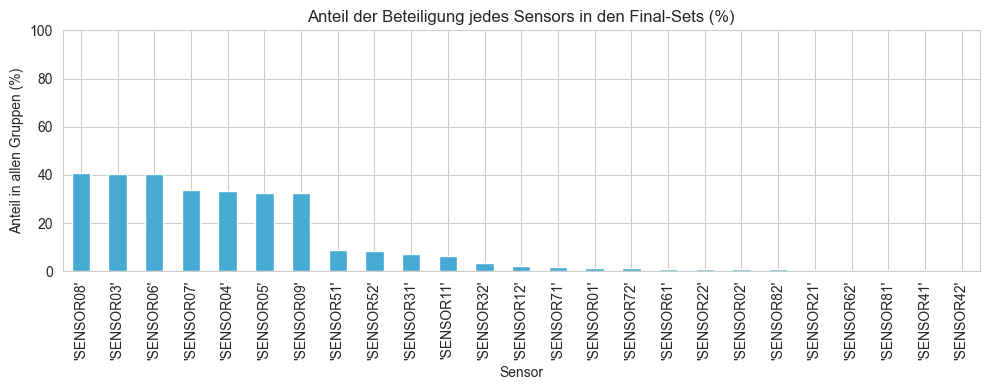

            count  percent
Sensor                    
'SENSOR08'   5318    40.69
'SENSOR03'   5277    40.38
'SENSOR06'   5254    40.20
'SENSOR07'   4410    33.74
'SENSOR04'   4385    33.55
'SENSOR05'   4259    32.59
'SENSOR09'   4259    32.59
'SENSOR51'   1155     8.84
'SENSOR52'   1081     8.27
'SENSOR31'    926     7.09
'SENSOR11'    845     6.47
'SENSOR32'    441     3.37
'SENSOR12'    297     2.27
'SENSOR71'    213     1.63
'SENSOR01'    161     1.23
'SENSOR72'    158     1.21
'SENSOR61'    120     0.92
'SENSOR22'    115     0.88
'SENSOR02'    110     0.84
'SENSOR82'    108     0.83
'SENSOR21'     90     0.69
'SENSOR62'     77     0.59
'SENSOR81'     70     0.54
'SENSOR41'     59     0.45
'SENSOR42'     19     0.15


In [32]:

# 1) Log-Datei einlesen und Final-Sets extrahieren
sets = []  # Liste von Tupeln (timestamp, tuple_of_sensors)
pattern = re.compile(r'\[(?P<time>\d{2}:\d{2}:\d{2})\] Final active set: \[(?P<sensors>[^\]]+)\]')

with open('sim_structural.log', 'r') as f:
    for line in f:
        m = pattern.search(line)
        if not m:
            continue
        t = pd.to_datetime(m.group('time'), format='%H:%M:%S')
        if t.second != 5:
            continue
        sensor_list = [s.strip() for s in m.group('sensors').split(',')]
        # Normiere Reihenfolge, damit Sets vergleichbar sind
        sensor_list_sorted = tuple(sorted(sensor_list))
        sets.append(sensor_list_sorted)

if not sets:
    raise RuntimeError("Keine Final active set-Einträge bei xx:05 gefunden.")

# 2) Zähle Häufigkeiten
flat = [sensor for s in sets for sensor in s]
sensor_counts = Counter(flat)

# 3) DataFrame (Prozent)
n_total = len(sets)  # Anzahl der Sets, d.h. wie viele Gruppen es gab
df_sensors = pd.DataFrame.from_dict(sensor_counts, orient='index', columns=['count'])
df_sensors['percent'] = 100 * df_sensors['count'] / n_total
df_sensors.index.name = 'Sensor'
df_sensors = df_sensors.sort_values('percent', ascending=False)

# 4) Plot
plt.figure(figsize=(10,4))
df_sensors['percent'].plot(kind='bar', color="#46aad2")
plt.title('Anteil der Beteiligung jedes Sensors in den Final-Sets (%)')
plt.ylabel('Anteil in allen Gruppen (%)')
plt.xlabel('Sensor')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Optional: Prozentwerte ausgeben
print(df_sensors[['count', 'percent']].round(2))


#    ################################
#  9.1 Wie oft waren bestimmte Sets von Sensoren aktiv nach der Redundanzcheck
#   ################################

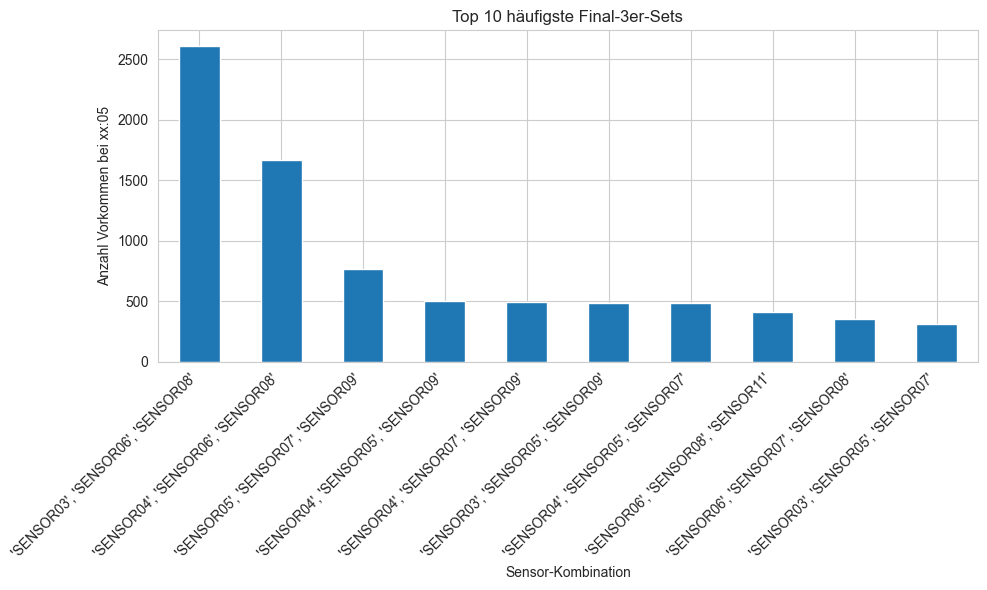

In [33]:
plt.figure(figsize=(10,6))
df_sets['count'].head(10).plot(kind='bar')
plt.title('Top 10 häufigste Final-3er-Sets')
plt.ylabel('Anzahl Vorkommen bei xx:05')
plt.xlabel('Sensor-Kombination')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Wie viele Gruppen insgesamt

In [34]:
# Anzahl der Gruppen ausgeben
n_groups = df_sets.shape[0]
plt.figtext(0.99, 0.01, f"Insgesamt verschiedene Gruppen: {n_groups}", 
            ha="right", va="bottom", fontsize=10, color="gray")
plt.show()

print("Insgesamt verschiedene Gruppen:", n_groups)


<Figure size 640x480 with 0 Axes>

Insgesamt verschiedene Gruppen: 193


# 10 Heatmap Sensoren zusammen im finallem Set Haufigkeit

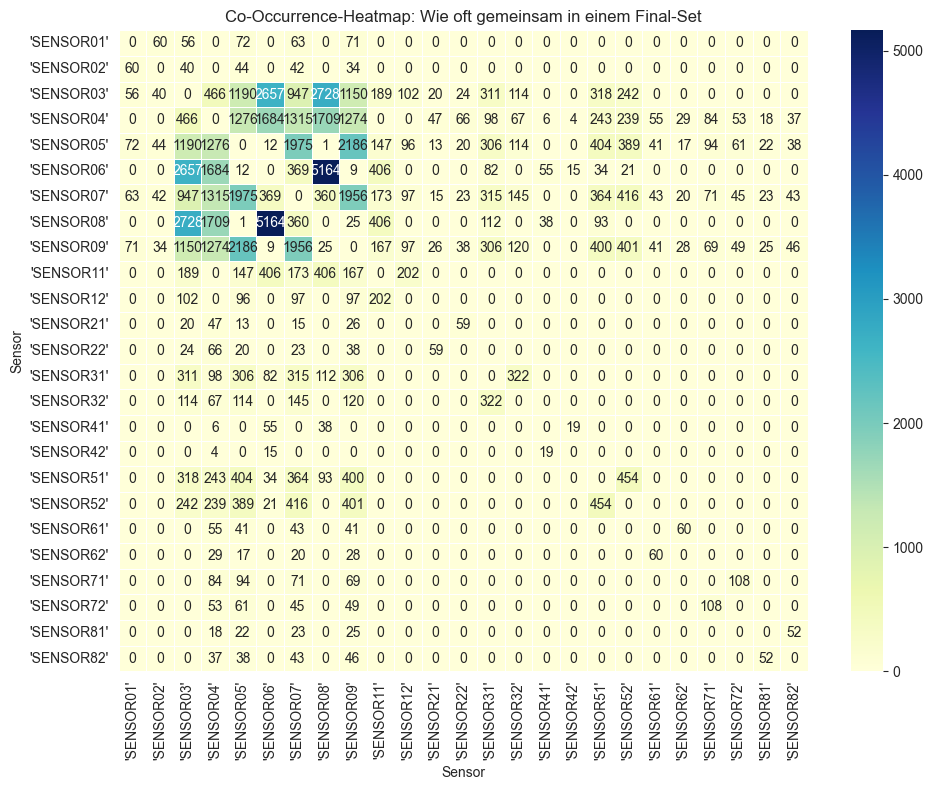

In [35]:
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

# Annahme: df_sets ist wie oben gebaut und der Index ist der Set-String
df_sets['set_list'] = df_sets.index.to_series().apply(lambda x: [s.strip() for s in x.split(',')])

# Zähle für jedes Paar, wie oft sie zusammen in einem Set sind (gewichtet nach count)
pair_counts = Counter()
for sensors, count in zip(df_sets['set_list'], df_sets['count']):
    for s1, s2 in itertools.combinations(sorted(sensors), 2):
        pair_counts[(s1, s2)] += count

# Alle Sensoren extrahieren
all_sensors = sorted({s for sensors in df_sets['set_list'] for s in sensors})

# Leeres DataFrame für Matrix
heatmap_df = pd.DataFrame(0, index=all_sensors, columns=all_sensors)
for (s1, s2), count in pair_counts.items():
    heatmap_df.loc[s1, s2] = count
    heatmap_df.loc[s2, s1] = count  # symmetrisch

# HEATMAP plotten!
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_df, cmap="YlGnBu", linewidths=0.5, annot=True, fmt='d')
plt.title("Co-Occurrence-Heatmap: Wie oft gemeinsam in einem Final-Set")
plt.xlabel("Sensor")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()


In [36]:
import itertools
import pandas as pd

# Annahme: df_sets ist wie oben gebaut und der Index ist der Set-String
df_sets['set_list'] = df_sets.index.to_series().apply(lambda x: [s.strip() for s in x.split(',')])

# Zähle für jedes Triplet, wie oft es zusammen in einem Set ist (gewichtet nach count)
triplet_counts = Counter()
for sensors, count in zip(df_sets['set_list'], df_sets['count']):
    for s1, s2, s3 in itertools.combinations(sorted(sensors), 3):
        triplet = tuple(sorted([s1, s2, s3]))
        triplet_counts[triplet] += count

# In DataFrame umwandeln und nach Häufigkeit sortieren
triplet_df = (
    pd.DataFrame([
        {'Sensor 1': t[0], 'Sensor 2': t[1], 'Sensor 3': t[2], 'Count': c}
        for t, c in triplet_counts.items()
    ])
    .sort_values('Count', ascending=False)
    .reset_index(drop=True)
)

# Zeige die Top 15 Triplets (kannst du beliebig erweitern)
print(triplet_df.head(15))

# Optional: Als Heatmap nicht sinnvoll (3D), aber du kannst ggf. noch andere Visualisierungsideen angeben!


      Sensor 1    Sensor 2    Sensor 3  Count
0   'SENSOR03'  'SENSOR06'  'SENSOR08'   2609
1   'SENSOR04'  'SENSOR06'  'SENSOR08'   1666
2   'SENSOR05'  'SENSOR07'  'SENSOR09'    768
3   'SENSOR04'  'SENSOR05'  'SENSOR09'    500
4   'SENSOR04'  'SENSOR07'  'SENSOR09'    492
5   'SENSOR03'  'SENSOR05'  'SENSOR09'    488
6   'SENSOR04'  'SENSOR05'  'SENSOR07'    484
7   'SENSOR06'  'SENSOR08'  'SENSOR11'    406
8   'SENSOR06'  'SENSOR07'  'SENSOR08'    356
9   'SENSOR03'  'SENSOR05'  'SENSOR07'    311
10  'SENSOR03'  'SENSOR07'  'SENSOR09'    281
11  'SENSOR03'  'SENSOR04'  'SENSOR07'    132
12  'SENSOR07'  'SENSOR51'  'SENSOR52'    117
13  'SENSOR05'  'SENSOR09'  'SENSOR51'    109
14  'SENSOR05'  'SENSOR09'  'SENSOR52'    108


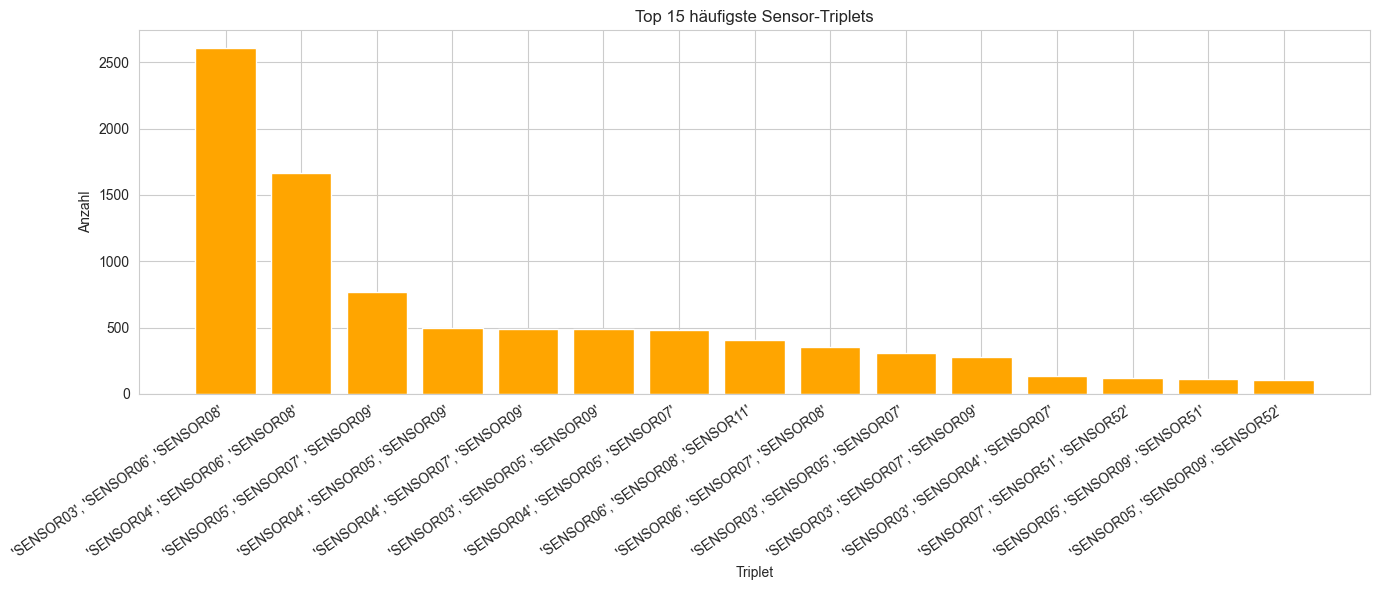

In [37]:
triplet_df_top = triplet_df.head(15)
triplet_labels = triplet_df_top.apply(lambda row: f"{row['Sensor 1']}, {row['Sensor 2']}, {row['Sensor 3']}", axis=1)
plt.figure(figsize=(14,6))
plt.bar(triplet_labels, triplet_df_top['Count'], color='orange')
plt.ylabel('Anzahl')
plt.xlabel('Triplet')
plt.title('Top 15 häufigste Sensor-Triplets')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [38]:
import itertools
import pandas as pd
from collections import Counter

# Angenommen, df_sets ist wie oben gebaut:
# df_sets['set_list'] enthält die Sensorlisten pro Set und df_sets['count'] die Häufigkeit

# Zähle für jedes Triplet, wie oft es zusammen in einem Set ist (gewichtet nach count)
triplet_counts = Counter()
for sensors, count in zip(df_sets['set_list'], df_sets['count']):
    for s1, s2, s3 in itertools.combinations(sorted(sensors), 3):
        triplet = tuple(sorted([s1, s2, s3]))
        triplet_counts[triplet] += count

# In DataFrame umwandeln und nach Häufigkeit sortieren
triplet_df = (
    pd.DataFrame([
        {'Sensor 1': t[0], 'Sensor 2': t[1], 'Sensor 3': t[2], 'Count': c}
        for t, c in triplet_counts.items()
    ])
    .sort_values('Count', ascending=False)
    .reset_index(drop=True)
)

# ---> Prozent berechnen <---
total = triplet_df['Count'].sum()
triplet_df['Percent'] = 100 * triplet_df['Count'] / total

# Schön runden (optional)
triplet_df['Percent'] = triplet_df['Percent'].round(2)

# Zeige die Top 15 Triplets in Prozent
print(triplet_df.head(15))

# Optional: Wenn du eine Tabelle im LaTeX-Stil willst
print(
    triplet_df.head(15)
    .apply(lambda row: f"{row['Sensor 1']} & {row['Sensor 2']} & {row['Sensor 3']} & {row['Percent']} \\\\", axis=1)
    .to_string(index=False)
)


      Sensor 1    Sensor 2    Sensor 3  Count  Percent
0   'SENSOR03'  'SENSOR06'  'SENSOR08'   2609    19.96
1   'SENSOR04'  'SENSOR06'  'SENSOR08'   1666    12.75
2   'SENSOR05'  'SENSOR07'  'SENSOR09'    768     5.88
3   'SENSOR04'  'SENSOR05'  'SENSOR09'    500     3.83
4   'SENSOR04'  'SENSOR07'  'SENSOR09'    492     3.76
5   'SENSOR03'  'SENSOR05'  'SENSOR09'    488     3.73
6   'SENSOR04'  'SENSOR05'  'SENSOR07'    484     3.70
7   'SENSOR06'  'SENSOR08'  'SENSOR11'    406     3.11
8   'SENSOR06'  'SENSOR07'  'SENSOR08'    356     2.72
9   'SENSOR03'  'SENSOR05'  'SENSOR07'    311     2.38
10  'SENSOR03'  'SENSOR07'  'SENSOR09'    281     2.15
11  'SENSOR03'  'SENSOR04'  'SENSOR07'    132     1.01
12  'SENSOR07'  'SENSOR51'  'SENSOR52'    117     0.90
13  'SENSOR05'  'SENSOR09'  'SENSOR51'    109     0.83
14  'SENSOR05'  'SENSOR09'  'SENSOR52'    108     0.83
'SENSOR03' & 'SENSOR06' & 'SENSOR08' & 19.96 \\
'SENSOR04' & 'SENSOR06' & 'SENSOR08' & 12.75 \\
 'SENSOR05' & 'SENSOR07'

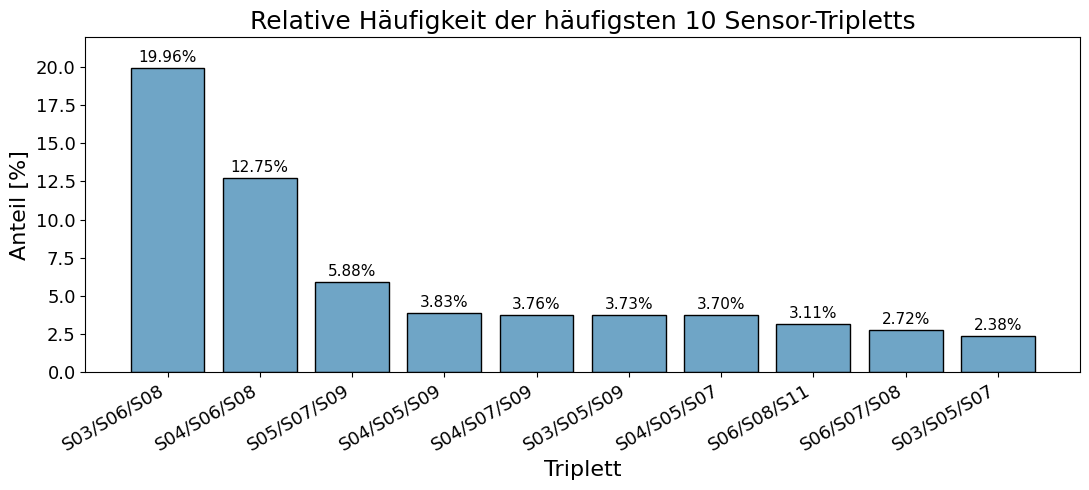

In [43]:
import matplotlib.pyplot as plt

# Wir nehmen die 10 häufigsten Triplets
top_n = 10
top_triplets = triplet_df.head(top_n)

def nice_triplet_label(row):
    l = [str(x).replace("'", "").replace("SENSOR", "S") for x in (row['Sensor 1'], row['Sensor 2'], row['Sensor 3'])]
    return '/'.join(l)

labels = top_triplets.apply(nice_triplet_label, axis=1)

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, top_triplets['Percent'], color="#6fa5c6", edgecolor="black")
plt.ylabel('Anteil [%]', fontsize=16)
plt.title('Relative Häufigkeit der häufigsten 10 Sensor-Tripletts', fontsize=18)
plt.xlabel('Triplett', fontsize=16)
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)

# Prozentwerte auf die Balken schreiben
for bar, percent in zip(bars, top_triplets['Percent']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{percent:.2f}%", ha='center', va='bottom', fontsize=11)

# --- HIER: Obergrenze für die Y-Achse festlegen ---
max_percent = top_triplets['Percent'].max()
plt.ylim(0, max_percent + 2)  # z.B. 2 Prozentpunkte Abstand oben

plt.tight_layout()
plt.savefig("ansatz_1_haufigkeit_temperature.jpg", dpi=300, format='jpeg')
plt.show()

